## Set Up

In [ ]:
# import libraries
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from inflation_forecast.pre_process import stationary_transform, report_missings, sample_split, remove_missing_col
from inflation_forecast.visualization import visualize_series, visualize_loss, visualize_predict
from inflation_forecast.feature_engineering import x_fe_pipeline, y_fe_pipeline, create_ahead_lag
from inflation_forecast.model import (
    create_data_loaders, 
    create_MLP, 
    nn_training, 
    make_predict, 
    create_RNN, 
    create_DL, 
    MLP_ensemble, 
    RNN_ensemble, 
    DL_ensemble
    )
from inflation_forecast.evaluation import compute_MSE, cross_validation_loss

In [2]:
# ignore performance warnings
import warnings
from pandas.errors import PerformanceWarning
from sklearn.exceptions import DataConversionWarning
warnings.simplefilter("ignore", PerformanceWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

## Data Pre-Process

In [3]:
# read the FRED_MD csv file, convert to pandas dataframe
root_dir = Path.cwd().parent
FRED_MD = pd.read_csv(str(root_dir) + "/data/FRED_MD/2026-02-MD.csv")
transforms = pd.read_csv(str(root_dir) + "/data/FRED_MD/transform.csv")

In [ ]:
# conduct stationarity transformations
FRED_transformed = stationary_transform(FRED_MD, transforms)
# drop first two rows as they have abundant NANs due to double difference
FRED_transformed = FRED_transformed.iloc[2:]
# drop last row as many variables of it has not been updated
FRED_transformed = FRED_transformed.iloc[:-1]
# transform sasdate to pd.date format
FRED_transformed["sasdate"] = pd.to_datetime(FRED_transformed["sasdate"])
FRED_MD["sasdate"] = pd.to_datetime(FRED_MD["sasdate"])

In [ ]:
# print missing value count and percentage in each column
print(report_missings(FRED_transformed))

0    sasdate                            |datetime64[us]                |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    RPI                                |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
2    W875RX1                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
3    DPCERA3M086SBEA                    |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
4    CMRMTSPLx                          |float64                       |Mis_count: 1                  |Uni_value: Mis_pct: 0.0012468827930174563
5    RETAILx                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
6    INDPRO                             |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
7    IPFPNSS                            |float64                       |Mis_count: 0         

In [6]:
# drop columns with > 10% missing values
FRED_transformed = remove_missing_col(FRED_transformed)
print(report_missings(FRED_transformed))

0    sasdate                            |datetime64[us]                |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    RPI                                |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
2    W875RX1                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
3    DPCERA3M086SBEA                    |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
4    CMRMTSPLx                          |float64                       |Mis_count: 1                  |Uni_value: Mis_pct: 0.0012468827930174563
5    RETAILx                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
6    INDPRO                             |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
7    IPFPNSS                            |float64                       |Mis_count: 0         

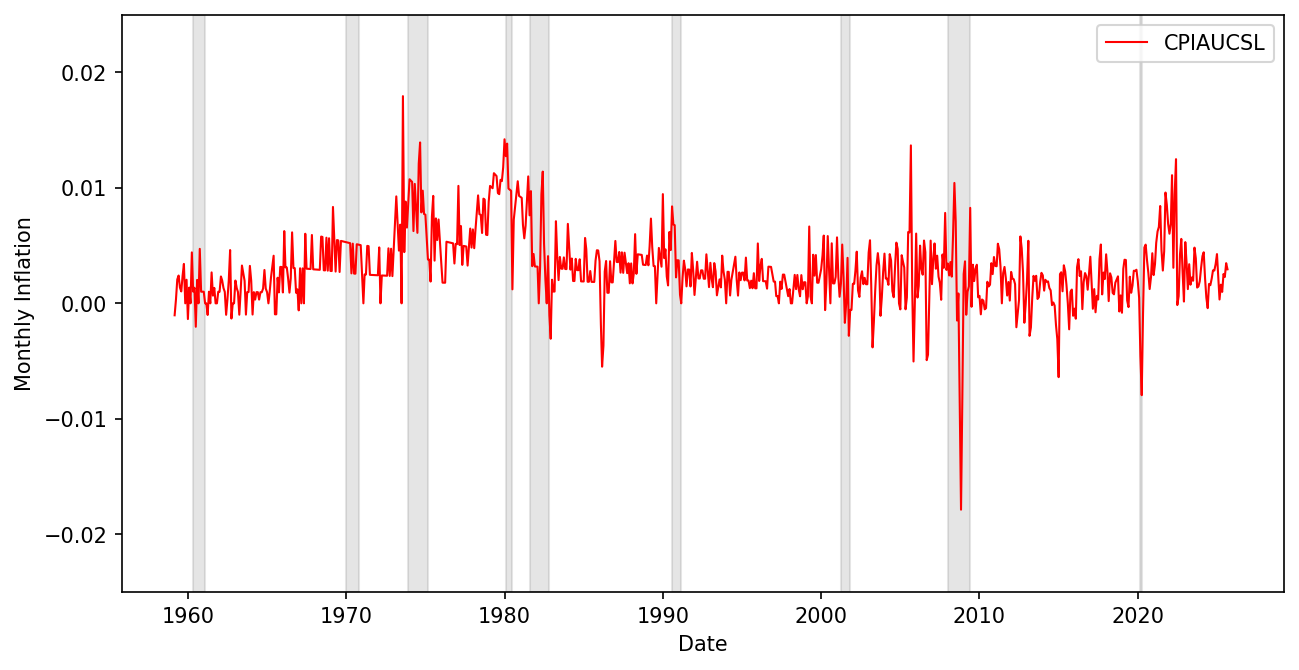

In [7]:
# plot CPIAUCSL over time
visualize_series(FRED_transformed, ["CPIAUCSL"], "Monthly Inflation", -0.025, 0.025)

In [8]:
# drop the date
FRED_transformed = FRED_transformed.drop(columns = ["sasdate"])

In [ ]:
# split train and test set
train_set, test_set = sample_split(FRED_transformed, 0.80)
# create feature engineering pipeline
x_feature_engineering = x_fe_pipeline(explained_var = 0.50)
y_feature_engineering = y_fe_pipeline()
# fit the feature engineering pipeline
x_feature_engineering.fit(train_set)
y_feature_engineering.fit(train_set)
# use the fitted pipeline to transform the whole dataset
x_train = x_feature_engineering.transform(train_set)
x_test = x_feature_engineering.transform(test_set)
y_train = y_feature_engineering.transform(train_set)[["CPIAUCSL"]]
y_test = y_feature_engineering.transform(test_set)[["CPIAUCSL"]]

## One Period Ahead Prediction

### FNN

In [ ]:
# create leads and lags for FNN
MLP_y_train, MLP_x_train, MLP_y_test, MLP_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, 0, include_target = True, target_lag = 11)

In [ ]:
# cross validate to select best neural network hyper parameter
nodes = [8, 12, 16]
epochs = [100, 300]
lrs = [0.001, 0.0001]
param_dict = {}
for node_size in nodes:
    for lr in lrs:
        for epoch in epochs:
            cv_loss = cross_validation_loss(None, "MLP", MLP_x_train, MLP_y_train, 5, 128, epoch, lr, node_size)
            param_dict[cv_loss] = {"node_size": node_size, "learning_rate": lr, "epochs": epoch}
lowest_loss = min(param_dict)
MLP_best_param = param_dict[lowest_loss]
print(lowest_loss)
print(MLP_best_param)

0.020850973095219504
{'node_size': 12, 'learning_rate': 0.001, 'epochs': 100}


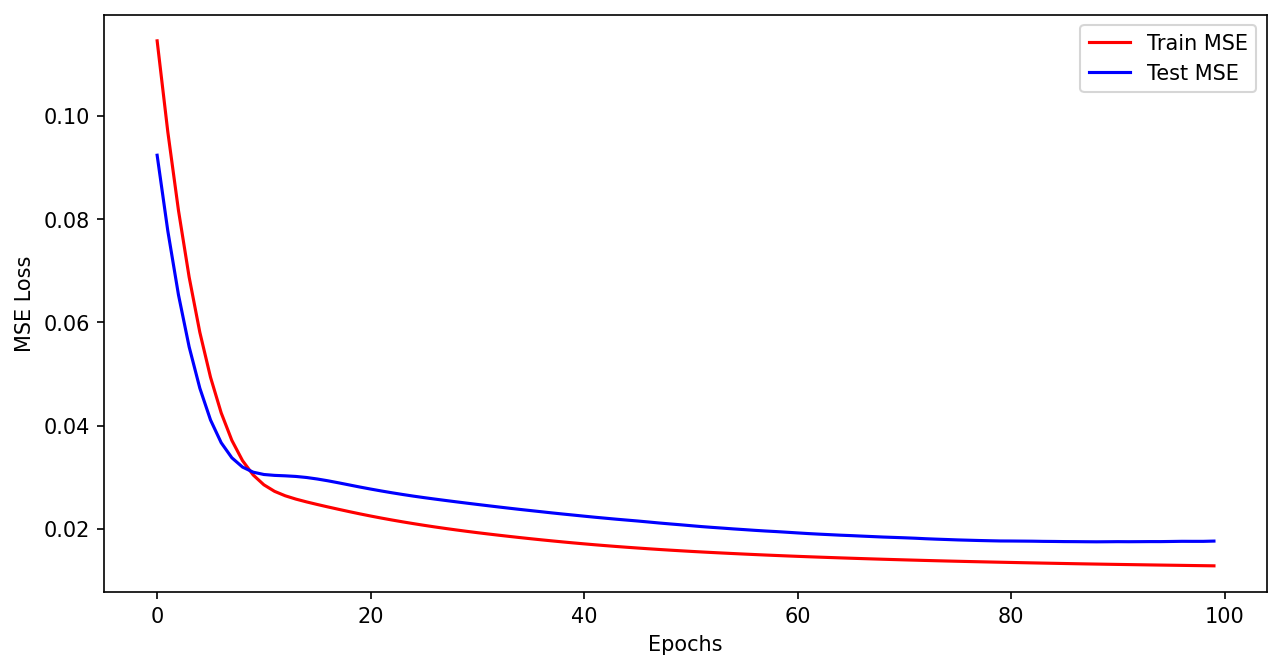

In [ ]:
# train a FNN using best hyper-parameter found
nodes = MLP_best_param["node_size"]
lr = MLP_best_param["learning_rate"]
epochs = MLP_best_param["epochs"]
train_loader, test_loader = create_data_loaders(MLP_x_train, MLP_y_train, MLP_x_test, MLP_y_test, 128)
MLP = create_MLP(MLP_x_train, MLP_y_train, nodes)
train_loss_list, test_loss_list = nn_training(MLP, train_loader, test_loader, epochs, lr, print_error = False)
visualize_loss(train_loss_list, test_loss_list)

Test MSE:0.017599502000408877, Test RMSE:0.13266311469435985


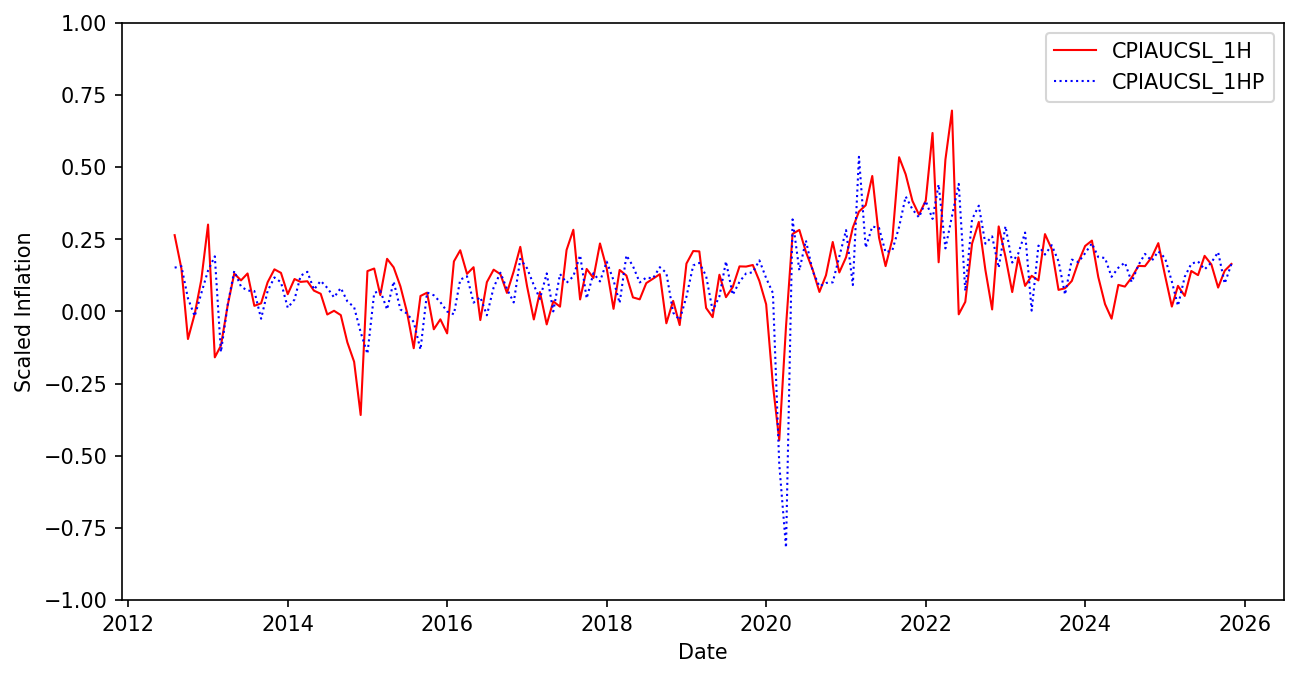

In [13]:
# plot prediction for testing set
prediction = make_predict(MLP, MLP_x_train, MLP_x_test, True)
visualize_predict(prediction, MLP_y_test, 1, FRED_MD)
MLP_MSE, MLP_RMSE = compute_MSE(prediction, MLP_y_test)
print(f"Test MSE:{MLP_MSE}, Test RMSE:{MLP_RMSE}")

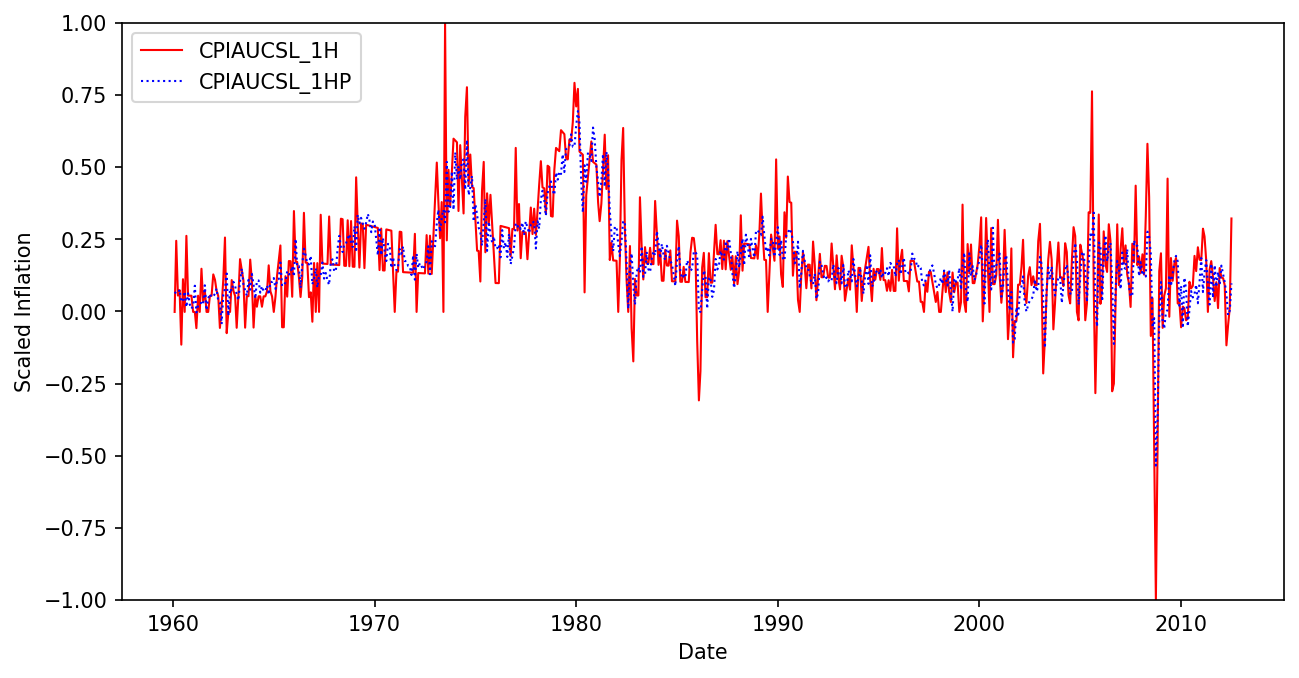

In [14]:
# plot prediction for training set
prediction = make_predict(MLP, MLP_x_train, MLP_x_test, False)
visualize_predict(prediction, MLP_y_train, 1, FRED_MD)

In [ ]:
# train 20 FNNs using best hyper-parameters found
nodes = MLP_best_param["node_size"]
lr = MLP_best_param["learning_rate"]
epochs = MLP_best_param["epochs"]
MLPE_prediction, MLP_models = MLP_ensemble(nodes, lr, epochs, 20, MLP_x_train, MLP_y_train, MLP_x_test, MLP_y_test)

Test MSE:0.014348136200474504, Test RMSE:0.1197837059055801


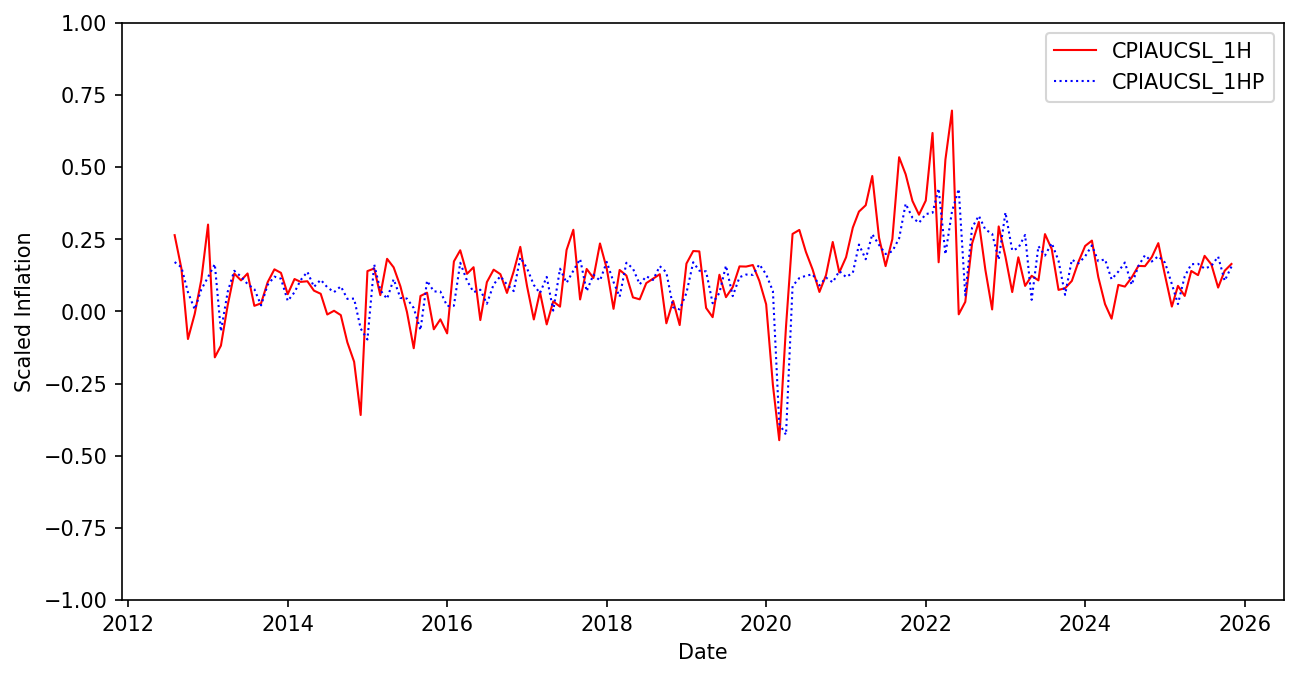

In [16]:
# plot the ensemble prediction on test set, compute MSE
visualize_predict(MLPE_prediction, MLP_y_test, 1, FRED_MD)
MLPE_MSE, MLPE_RMSE = compute_MSE(MLPE_prediction, MLP_y_test)
print(f"Test MSE:{MLPE_MSE}, Test RMSE:{MLPE_RMSE}")

### LSTM

In [ ]:
# create leads and lags for LSTM
RNN_y_train, RNN_x_train, RNN_y_test, RNN_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, 0, include_target = True, target_lag = 0)

In [ ]:
# cross validate to select best hyper parameters
nodes = [8, 12, 16]
hidden_sizes = [8, 12, 16]
window_sizes = [6, 12]
param_dict = {}
for node_size in nodes:
    for hidden_size in hidden_sizes:
        for window_size in window_sizes:
            cv_loss = cross_validation_loss(None, "RNN", RNN_x_train, RNN_y_train, 5, 128, 100, 0.001, node_size, hidden_size, window_size)
            param_dict[cv_loss] = {"node_size": node_size, "hidden_size": hidden_size, "window_size": window_size}
lowest_loss = min(param_dict)
RNN_best_param = param_dict[lowest_loss]
print(lowest_loss)
print(RNN_best_param)

0.02898104892611425
{'node_size': 12, 'hidden_size': 16, 'window_size': 12}


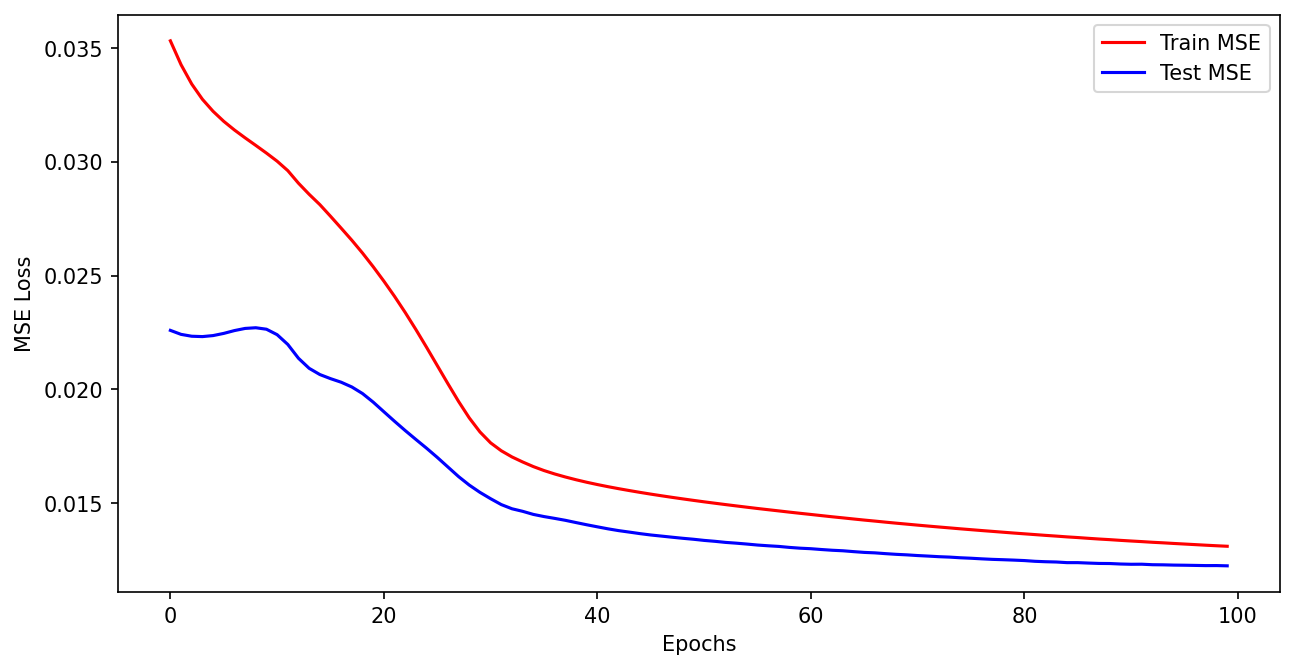

In [ ]:
# train a LSTM using best hyper-parameters found
nodes = RNN_best_param["node_size"]
hidden_size = RNN_best_param["hidden_size"]
window_size = RNN_best_param["window_size"]
RNN = create_RNN(RNN_x_train, RNN_y_train, hidden_size, nodes)
train_loader, test_loader = create_data_loaders(RNN_x_train, RNN_y_train, RNN_x_test, RNN_y_test, 128, window_size)
train_loss_list, test_loss_list = nn_training(RNN, train_loader, test_loader, 100, 0.001, print_error = False)
visualize_loss(train_loss_list, test_loss_list)

Test MSE:0.020896898102589587, Test RMSE:0.14455759441340185


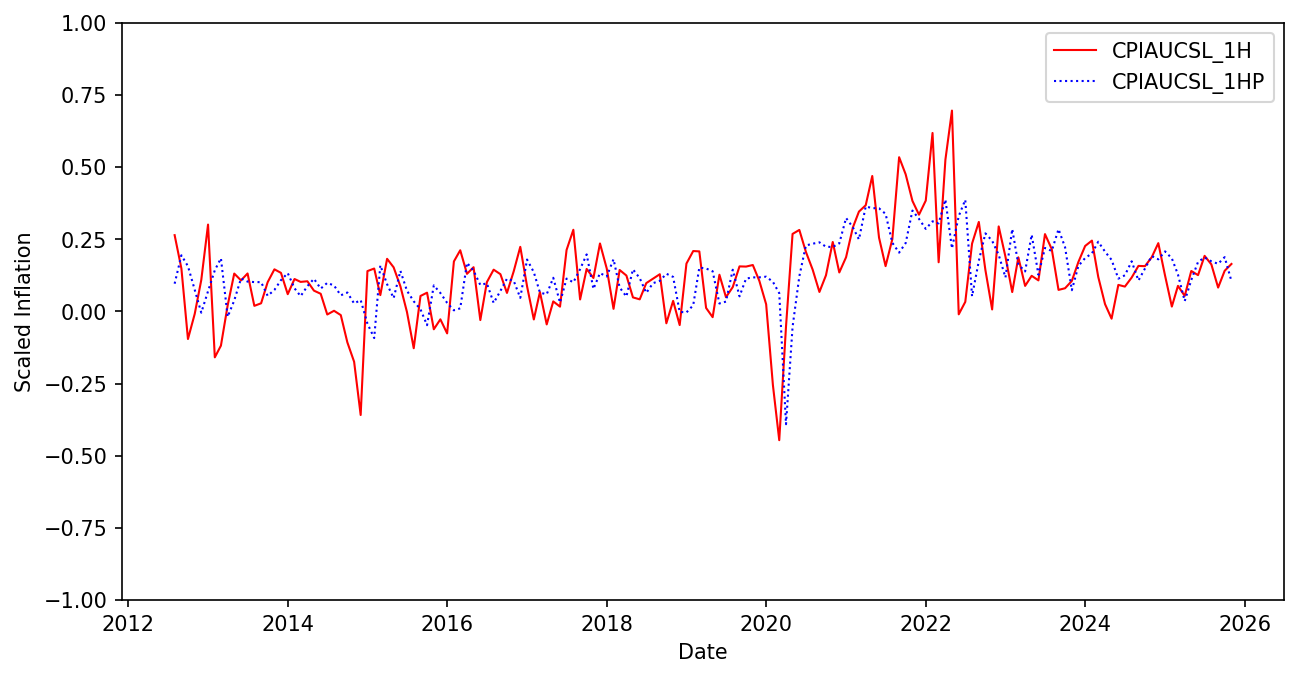

In [ ]:
# plot prediction for testing set
prediction = make_predict(RNN, RNN_x_train, RNN_x_test, True, window_size)
visualize_predict(prediction, RNN_y_test, 1, FRED_MD)
RNN_MSE, RNN_RMSE = compute_MSE(prediction, RNN_y_test)
print(f"Test MSE:{RNN_MSE}, Test RMSE:{RNN_RMSE}")

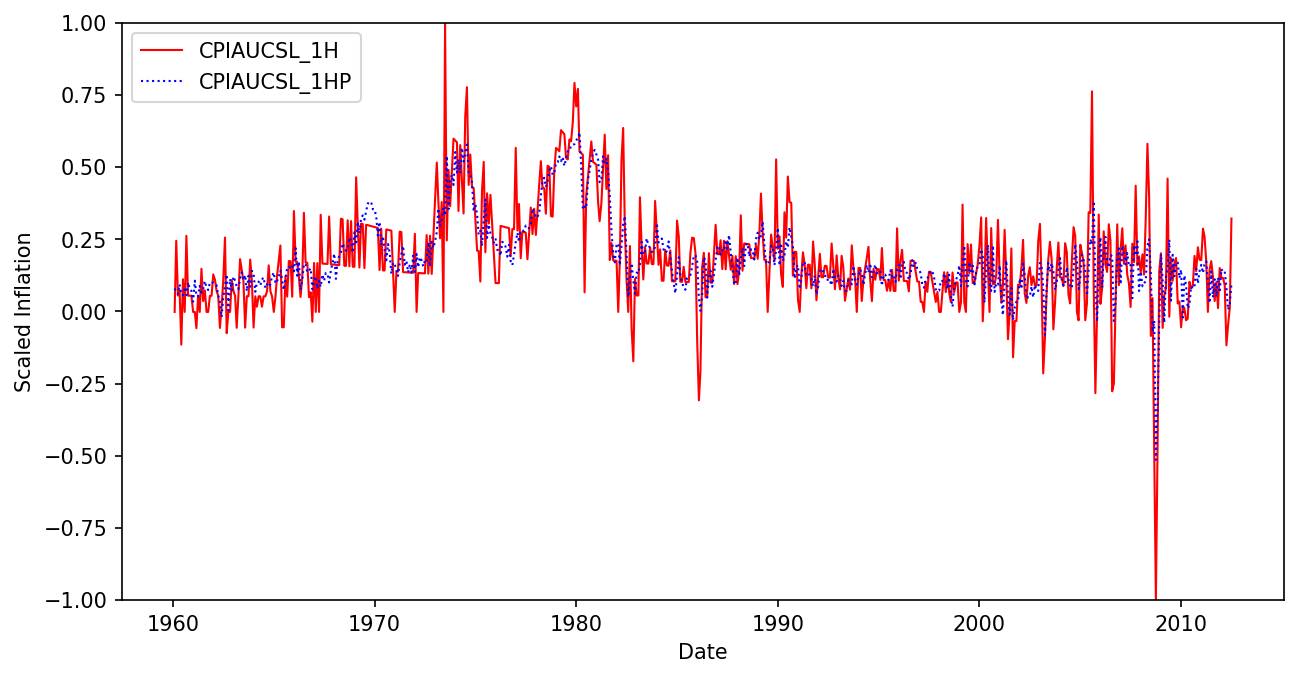

In [ ]:
# plot prediction for train set
prediction = make_predict(RNN, RNN_x_train, RNN_x_test, False, window_size)
visualize_predict(prediction, RNN_y_train[window_size-1:], 1, FRED_MD)

In [22]:
# train 20 LSTMs using best hyper-parameter found
nodes = RNN_best_param["node_size"]
hidden_size = RNN_best_param["hidden_size"]
window_size = RNN_best_param["window_size"]
RNNE_prediction, RNN_models = RNN_ensemble(nodes, hidden_size, window_size, 20, RNN_x_train, RNN_y_train, RNN_x_test, RNN_y_test)

Test MSE:0.020657182355831916, Test RMSE:0.1437260670714673


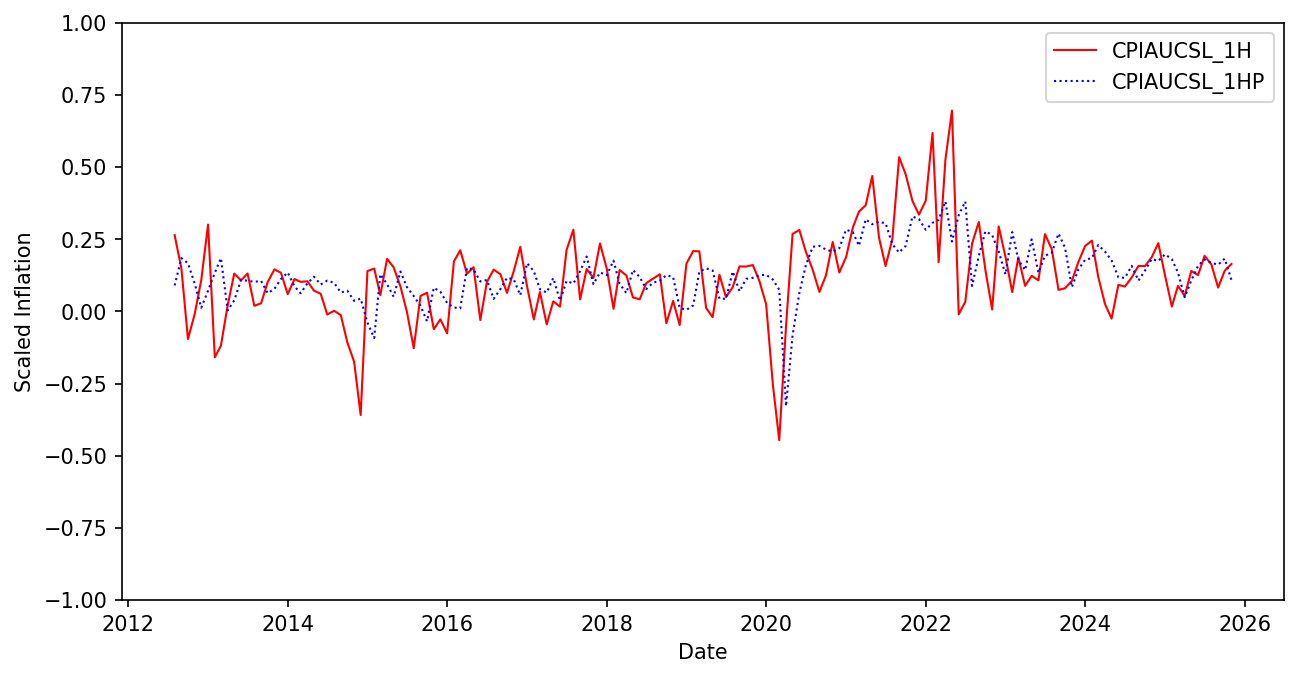

In [23]:
# plot ensemble prediction on test set, compute MSE
visualize_predict(RNNE_prediction, RNN_y_test, 1, FRED_MD)
RNNE_MSE, RNNE_RMSE = compute_MSE(RNNE_prediction, RNN_y_test)
print(f"Test MSE:{RNNE_MSE}, Test RMSE:{RNNE_RMSE}")

### Dlinear

In [ ]:
# create leads and lags for Dlinear
DL_y_train, DL_x_train, DL_y_test, DL_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, -1, include_target = True, target_lag = 0)

In [25]:
# cross validation to select best neural network hyper parameter
kernel_sizes = [15, 25, 35]
window_sizes = [6, 12, 16]
# individuals = [False, True]
param_dict = {}
for kernel_size in kernel_sizes:
    # for individual in individuals:
    for window_size in window_sizes:
        cv_loss = cross_validation_loss(None, "DL", DL_x_train, DL_y_train, 5, 128, 100, 0.001, None, None, window_size, True, kernel_size)
        param_dict[cv_loss] = {"kernel_size": kernel_size, "window_size": window_size}
lowest_loss = min(param_dict)
DL_best_param = param_dict[lowest_loss]
print(lowest_loss)
print(DL_best_param)

0.025744913270568846
{'kernel_size': 25, 'window_size': 12}


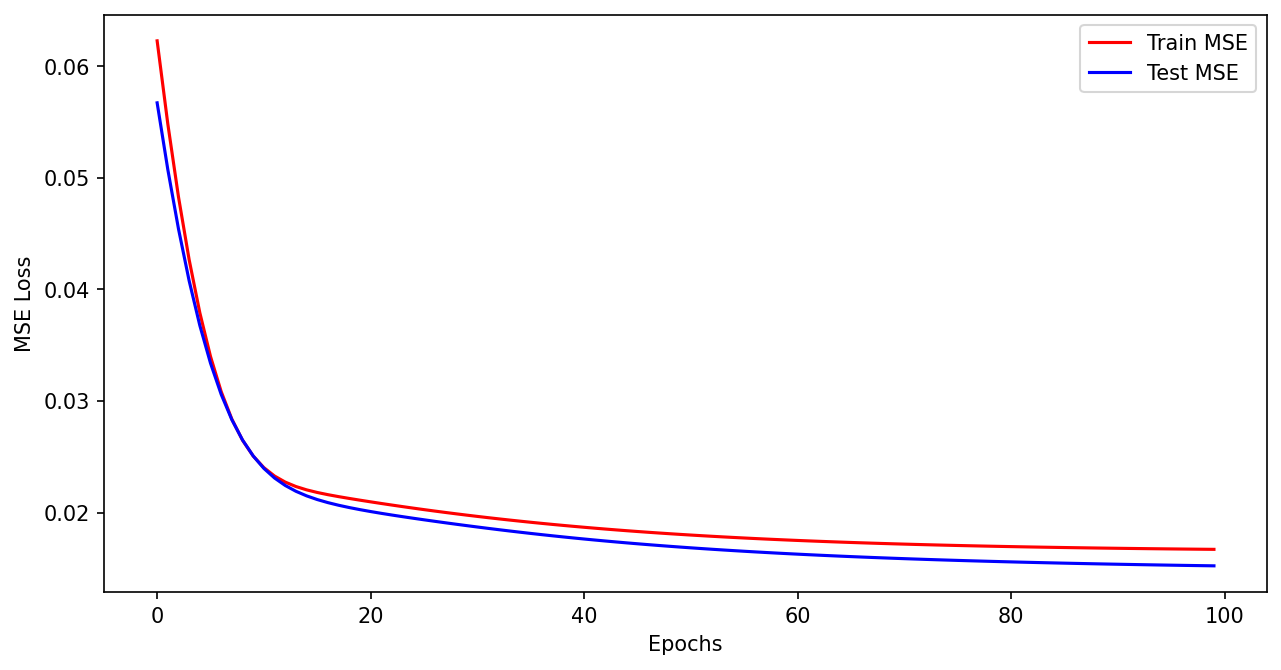

In [ ]:
# train a Dlinear using best hyper parameters found
window_size = DL_best_param["window_size"]
kernel_size = DL_best_param["kernel_size"]
DL = create_DL(DL_x_train, DL_y_train, window_size, True, kernel_size)
train_loader, test_loader = create_data_loaders(DL_x_train, DL_y_train, DL_x_test, DL_y_test, 128, window_size)
train_loss_list, test_loss_list = nn_training(DL, train_loader, test_loader, 100, 0.001, print_error = False, DL = False)
visualize_loss(train_loss_list, test_loss_list)

Test MSE:0.020462850722319688, Test RMSE:0.1430484209011749


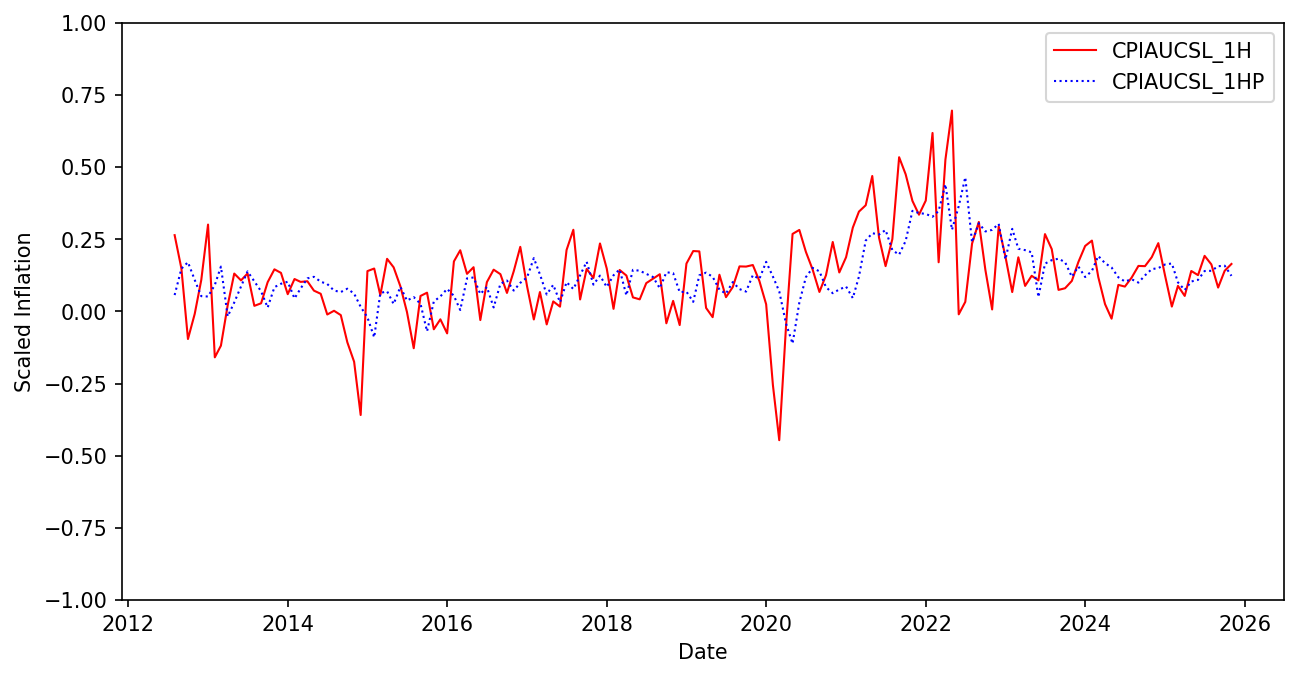

In [27]:
# plot prediction on test set, compute MSE
prediction = make_predict(DL, DL_x_train, DL_x_test, True, window_size)
visualize_predict(prediction, DL_y_test, 1, FRED_MD)
DL_MSE, DL_RMSE = compute_MSE(prediction, DL_y_test)
print(f"Test MSE:{DL_MSE}, Test RMSE:{DL_RMSE}")

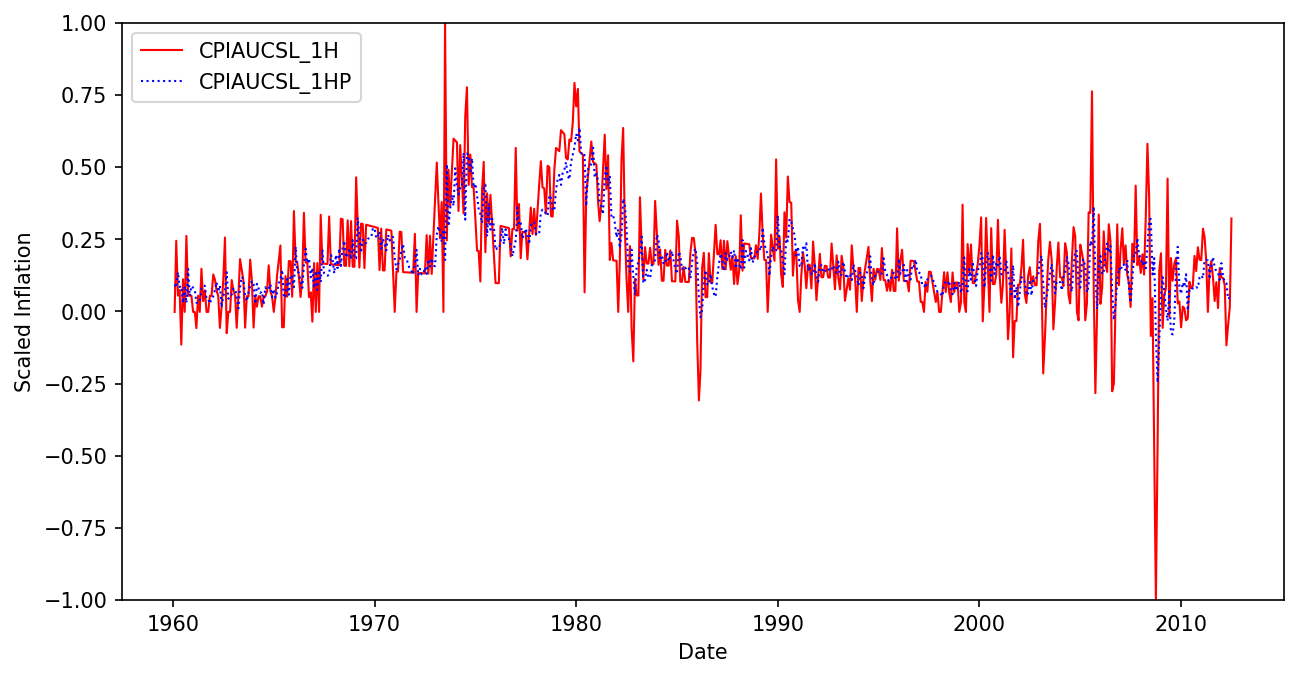

In [ ]:
# plot prediction on train set
prediction = make_predict(DL, DL_x_train, DL_x_test, False, window_size)
visualize_predict(prediction, DL_y_train[window_size-1:], 1, FRED_MD)

In [29]:
# train 20 DLs using best hyper-parameter found
window_size = DL_best_param["window_size"]
kernel_size = DL_best_param["kernel_size"]
DLE_prediction, DL_models = DL_ensemble(kernel_size, True, window_size, 20, DL_x_train, DL_y_train, DL_x_test, DL_y_test)

Test MSE:0.020290105911106863, Test RMSE:0.14244334281077112


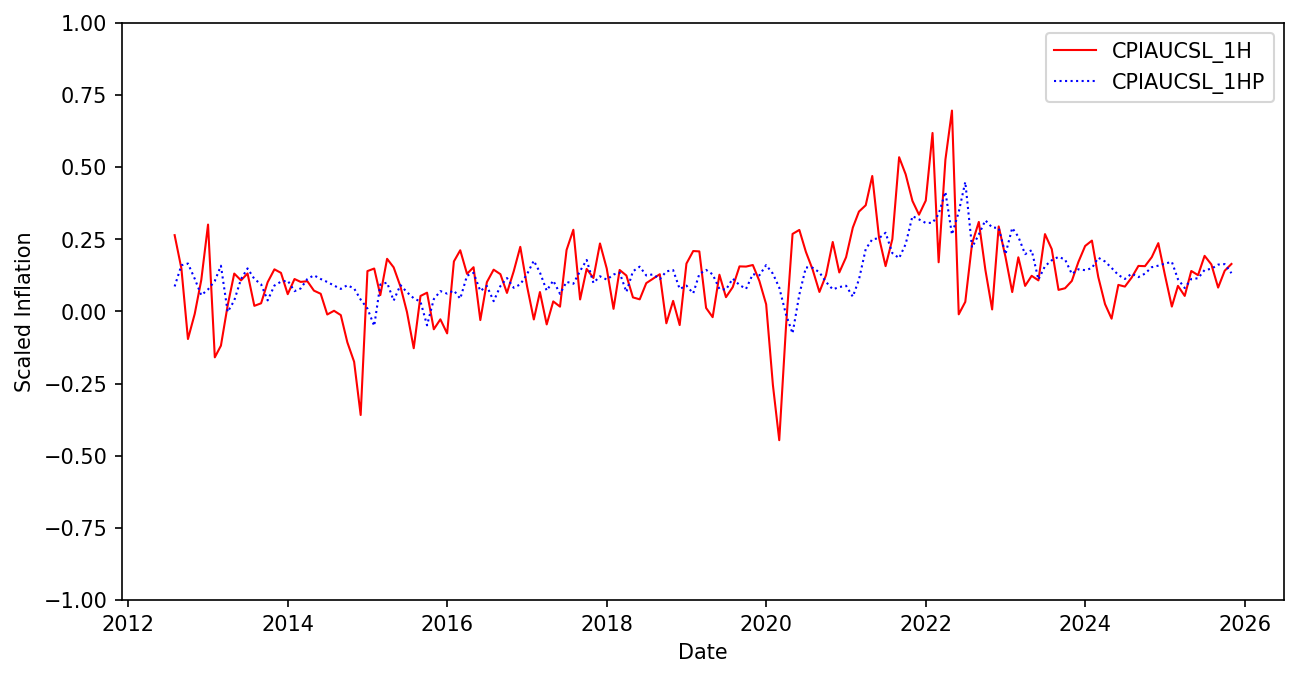

In [30]:
# plot ensemble prediction on test set, compute MSE
visualize_predict(DLE_prediction, DL_y_test, 1, FRED_MD)
DLE_MSE, DLE_RMSE = compute_MSE(DLE_prediction, DL_y_test)
print(f"Test MSE:{DLE_MSE}, Test RMSE:{DLE_RMSE}")

### AR

In [ ]:
# cross validate to select best AR lag
lags = [3, 7, 11, 15, 19, 23]
param_dict = {}
for lag in lags:
    AR_y_train, AR_x_train, AR_y_test, AR_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, -1, include_target = True, target_lag = lag)
    AR_model = LinearRegression()
    cv_loss = cross_validation_loss(AR_model, "scikit", AR_x_train, AR_y_train)
    param_dict[cv_loss] = {"lag": lag}
lowest_loss = min(param_dict)
AR_best_param = param_dict[lowest_loss]
print(lowest_loss)
print(AR_best_param)

0.020248678330929786
{'lag': 11}


In [118]:
# create train and test set for AR model with best lag
lag = AR_best_param["lag"]
AR_y_train, AR_x_train, AR_y_test, AR_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, -1, include_target = True, target_lag = lag)
# fit an AR model with best lag
AR_model = LinearRegression()
AR_model.fit(AR_x_train, AR_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


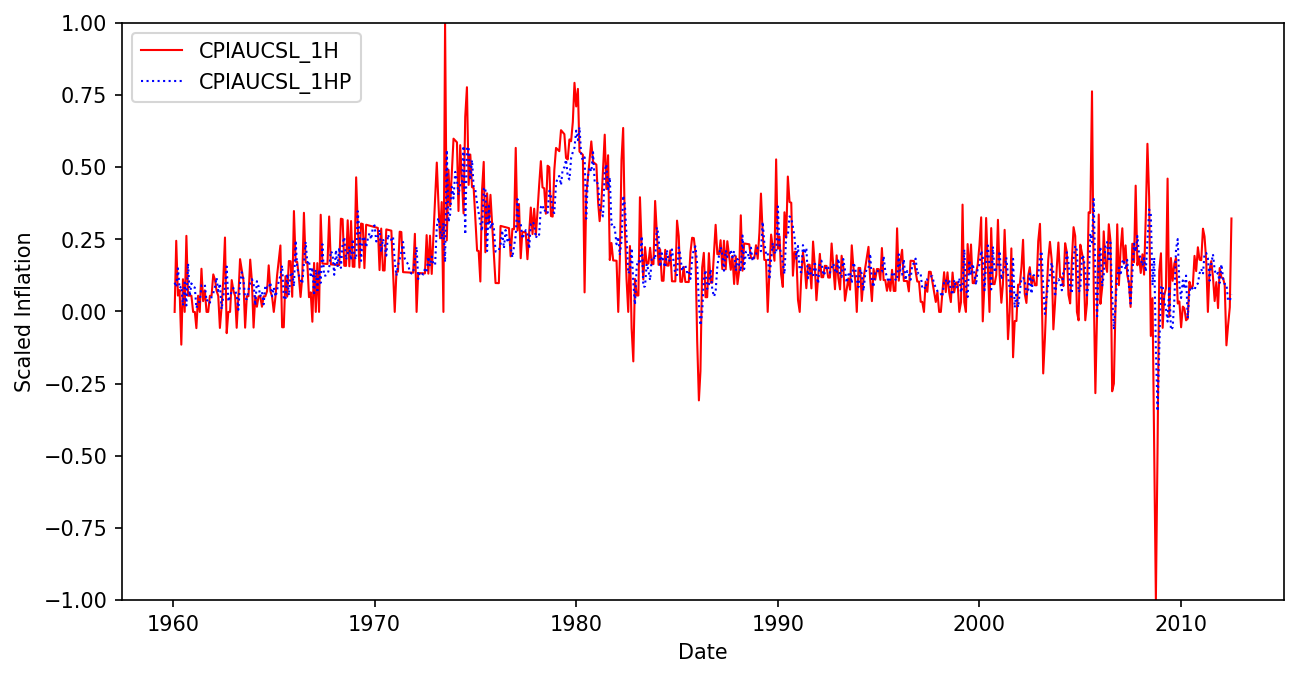

In [119]:
# get prediction on train set
prediction = AR_model.predict(AR_x_train)
visualize_predict(prediction, AR_y_train, 1, FRED_MD)

Test MSE:0.015085137035493537, Test RMSE:0.12282156584042371


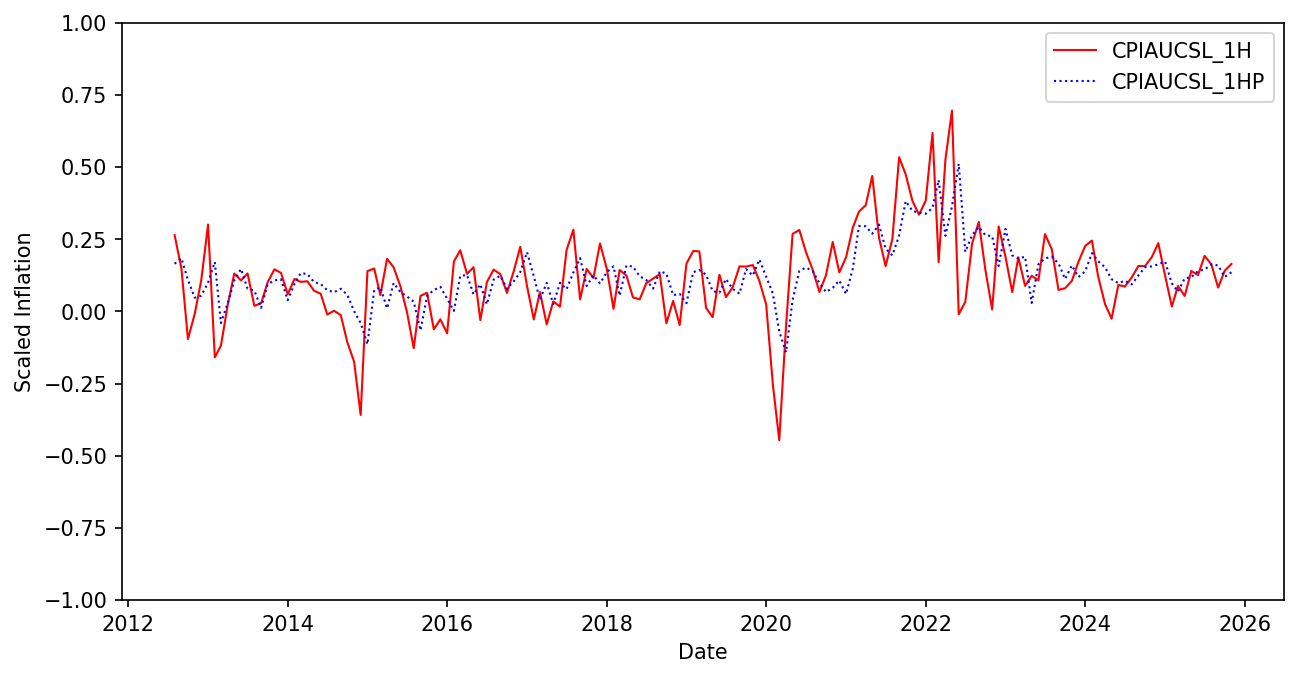

In [120]:
# get prediction on test set
prediction = AR_model.predict(AR_x_test)
visualize_predict(prediction, AR_y_test, 1, FRED_MD)
AR_MSE, AR_RMSE = compute_MSE(prediction, AR_y_test)
print(f"Test MSE:{AR_MSE}, Test RMSE:{AR_RMSE}")

### ARDL

In [ ]:
# cross validate to select best ARDL lags
y_lags = [3, 7, 11, 15, 19, 23]
x_lags = [0, 3, 7, 11, 15, 19, 23]
param_dict = {}
for y_lag in y_lags:
    for x_lag in x_lags:
        ARDL_y_train, ARDL_x_train, ARDL_y_test, ARDL_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, x_lag, include_target = True, target_lag = y_lag - 1)
        ARDL_model = LinearRegression()
        cv_loss = cross_validation_loss(ARDL_model, "scikit", ARDL_x_train, ARDL_y_train)
        param_dict[cv_loss] = {"x_lag": x_lag, "y_lag": y_lag}
lowest_loss = min(param_dict)
ARDL_best_param = param_dict[lowest_loss]
print(lowest_loss)
print(ARDL_best_param)

0.02001115582722119
{'x_lag': 0, 'y_lag': 7}


In [ ]:
# create train and test set for ARDL model with best lag
x_lag = ARDL_best_param["x_lag"]
y_lag = ARDL_best_param["y_lag"]
ARDL_y_train, ARDL_x_train, ARDL_y_test, ARDL_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, x_lag, include_target = True, target_lag = y_lag - 1)
# fit an ARDL model with best lag
ARDL_model = LinearRegression()
ARDL_model.fit(ARDL_x_train, ARDL_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


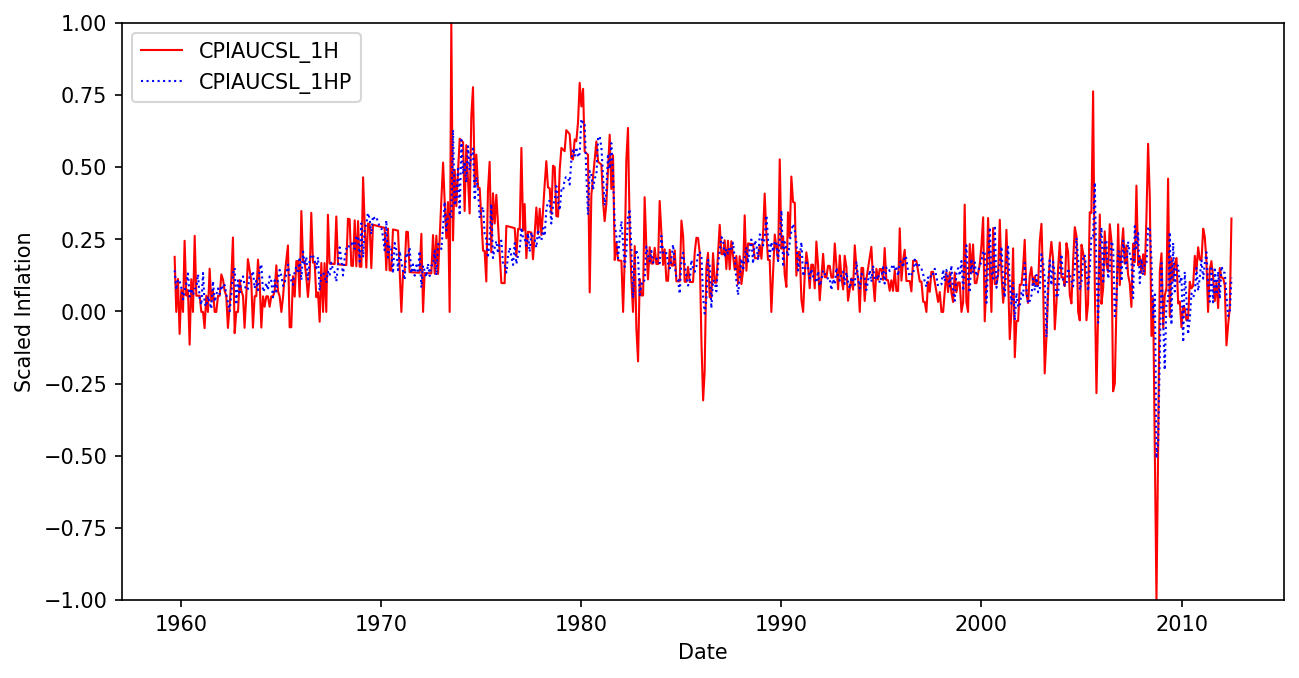

In [115]:
# get prediction on train set
prediction = ARDL_model.predict(ARDL_x_train)
visualize_predict(prediction, ARDL_y_train, 1, FRED_MD)

Test MSE:0.014661358317377637, Test RMSE:0.12108409605467449


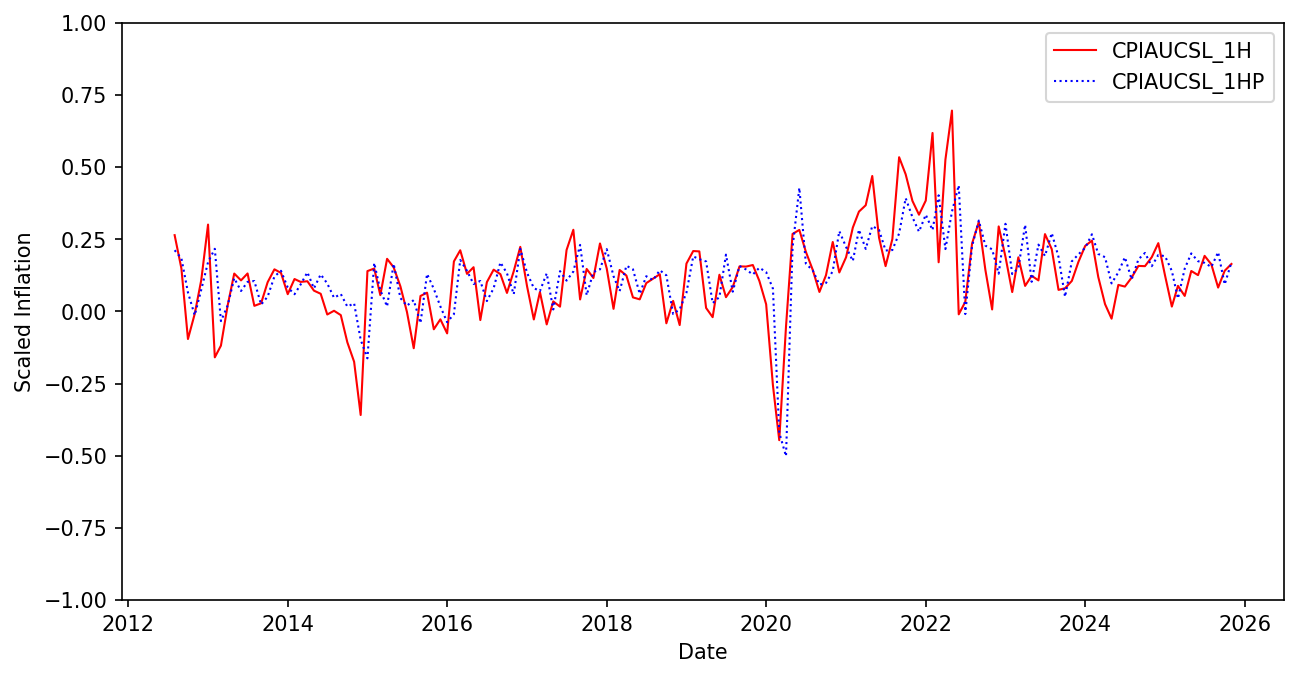

In [116]:
# get prediction on test set
prediction = ARDL_model.predict(ARDL_x_test)
visualize_predict(prediction, ARDL_y_test, 1, FRED_MD)
ARDL_MSE, ARDL_RMSE = compute_MSE(prediction, ARDL_y_test)
print(f"Test MSE:{ARDL_MSE}, Test RMSE:{ARDL_RMSE}")

### LASSO

In [ ]:
# create leads and lags for ridge regression
LASSO_y_train, LASSO_x_train, LASSO_y_test, LASSO_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, 11, include_target = True, target_lag = 11)

In [112]:
# select optimal penalty coefficient using CV
alphas = [0.1, 0.02, 0.01, 0.002, 0.001]
param_dict = {}
for alpha in alphas:
    LASSO = Pipeline([("scaler", StandardScaler()),("LASSO", Lasso(alpha = alpha))])
    cv_loss = cross_validation_loss(LASSO, "scikit", LASSO_x_train, LASSO_y_train)
    param_dict[cv_loss] = {"alpha": alpha}
lowest_loss = min(param_dict)
LASSO_best_param = param_dict[lowest_loss]
print(lowest_loss)
print(LASSO_best_param)

0.0379962298723973
{'alpha': 0.01}


In [108]:
# fit LASSO using optimal alpha
alpha = LASSO_best_param["alpha"]
LASSO = Pipeline([("scaler", StandardScaler()),("LASSO", Lasso(alpha = alpha))])
LASSO.fit(LASSO_x_train, LASSO_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('LASSO', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.02
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [109]:
# princt non-zero coefficients of LASSO model
coef = pd.Series(LASSO.named_steps["LASSO"].coef_, index=LASSO_x_train.columns)
selected_vars = coef[coef != 0]
print(selected_vars)

pca1           -0.028478
CPIAUCSL_0L     0.056074
CPIAUCSL_1L     0.000398
CPIAUCSL_3L     0.005578
CPIAUCSL_5L     0.003751
CPIAUCSL_6L     0.002524
CPIAUCSL_8L     0.012625
CPIAUCSL_9L     0.005336
CPIAUCSL_10L    0.008300
dtype: float64


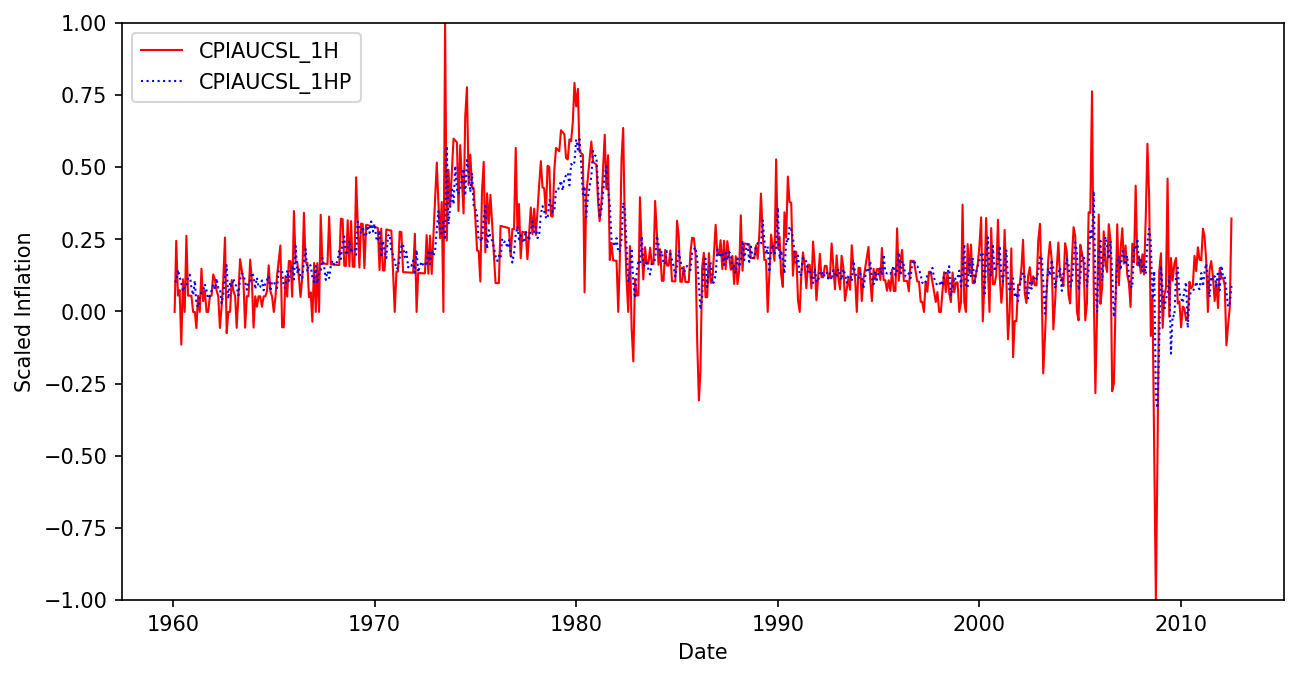

In [ ]:
# plot prediction on train set
prediction = LASSO.predict(LASSO_x_train)
visualize_predict(prediction, LASSO_y_train, 1, FRED_MD)

Test MSE:0.03056208318140446, Test RMSE:0.1748201452390555


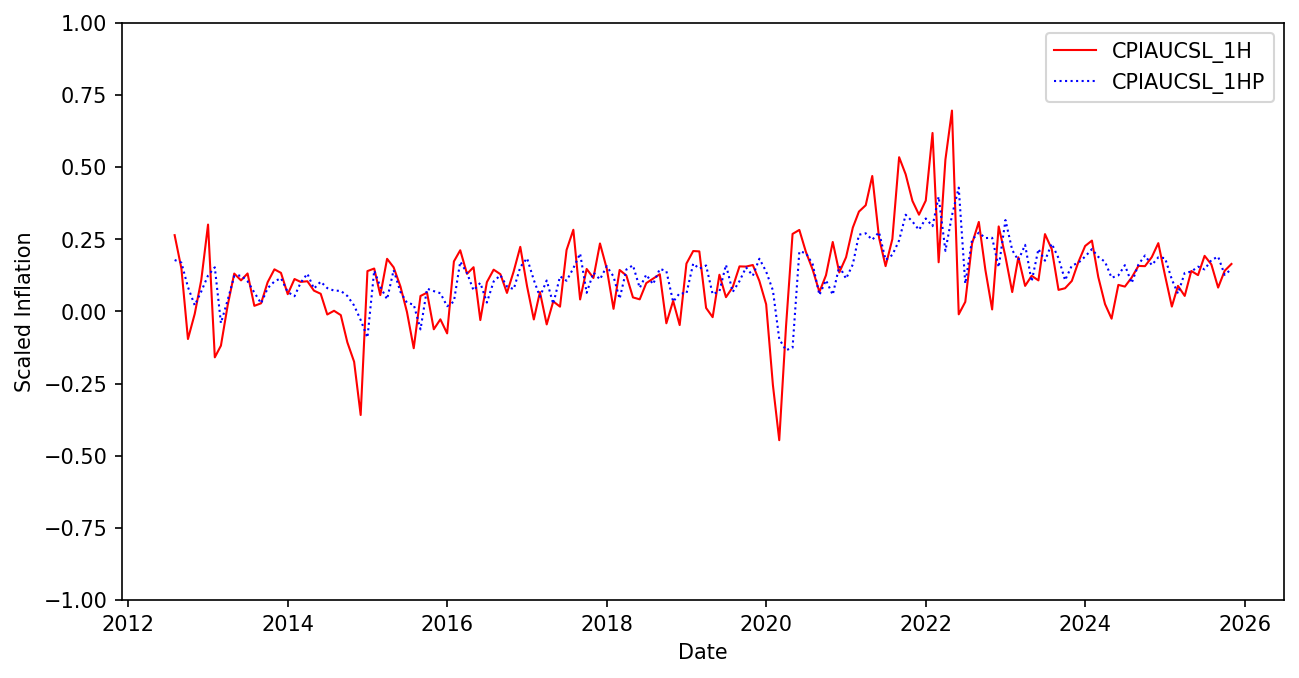

In [ ]:
# plot prediction on test set
prediction = LASSO.predict(LASSO_x_test)
visualize_predict(prediction, LASSO_y_test, 1, FRED_MD)
LASSO_MSE, LASSO_RMSE = compute_MSE(prediction, LASSO_y_test)
print(f"Test MSE:{LASSO_MSE}, Test RMSE:{LASSO_RMSE}")

### Random Forest

In [45]:
# create train and test set for random forest
RF_y_train, RF_x_train, RF_y_test, RF_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, 11, include_target = True, target_lag = 11)

In [ ]:
# select optimal hyper-parameters using CV
n_estimators = [100, 200, 500]
min_samples_splits = [2, 4, 6]
param_dict = {}
for n_estimator in n_estimators:
    for min_samples_split in min_samples_splits:
        RF = RandomForestRegressor(n_estimators = n_estimator, min_samples_split = min_samples_split)
        cv_loss = cross_validation_loss(RF, "scikit", RF_x_train, RF_y_train)
        param_dict[cv_loss] = {"n_estimator": n_estimator, "min_samples_split":min_samples_split}
lowest_loss = min(param_dict)
RF_best_param = param_dict[lowest_loss]
print(lowest_loss)
print(RF_best_param)

0.0357693861963798
{'n_estimator': 500, 'min_samples_split': 4}


In [ ]:
# train a random forest using best hyper parameters found
n_estimator = RF_best_param["n_estimator"]
min_samples_split = 5
RF = RandomForestRegressor(n_estimators = n_estimator, min_samples_split = min_samples_split, max_features = 0.33)
RF.fit(RF_x_train, RF_y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.33
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

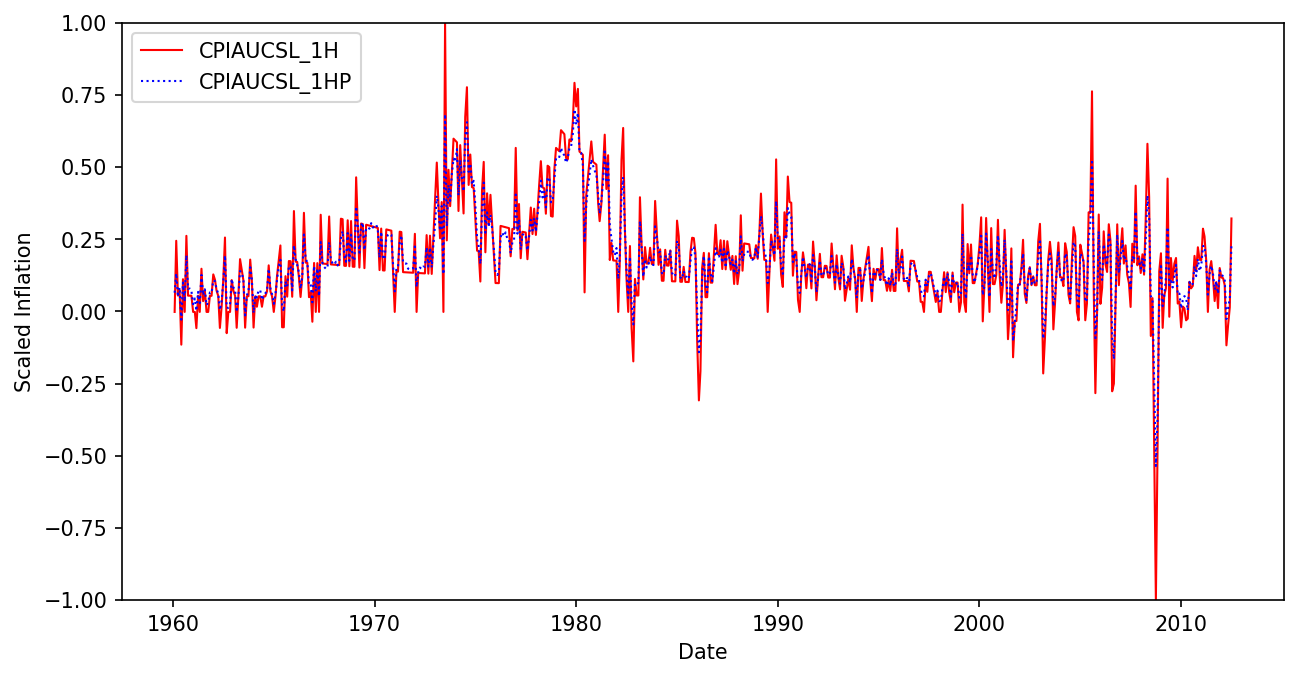

In [ ]:
# plot prediction on train set
prediction = RF.predict(RF_x_train)
visualize_predict(prediction, RF_y_train, 1, FRED_MD)

Test MSE:0.027911440080912283, Test RMSE:0.16706717236163507


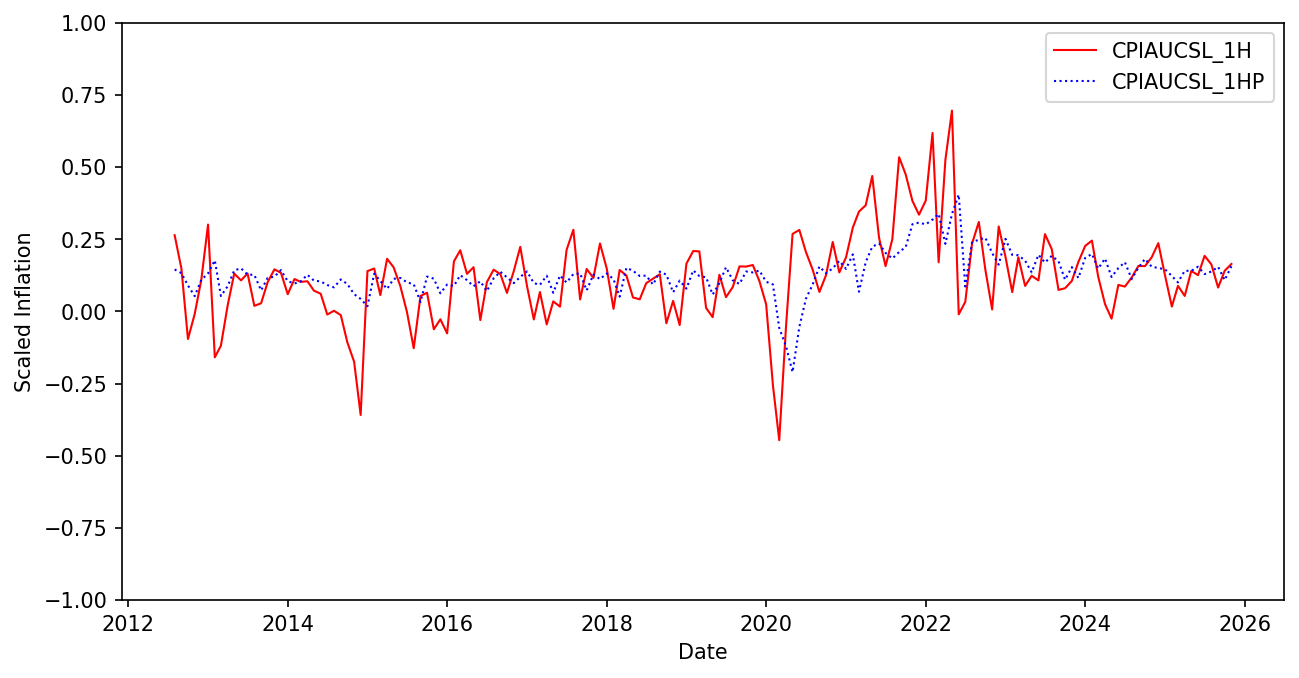

In [ ]:
# plot prediction on test set
prediction = RF.predict(RF_x_test)
visualize_predict(prediction, RF_y_test, 1, FRED_MD)
RF_MSE, RF_RMSE = compute_MSE(prediction, RF_y_test)
print(f"Test MSE:{RF_MSE}, Test RMSE:{RF_RMSE}")

### Gradient Boosting Machine

In [ ]:
# create leads and lags set for GBM
GBM_y_train, GBM_x_train, GBM_y_test, GBM_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, 11, include_target = True, target_lag = 11)

In [51]:
# select optimal hyper-parameter using CV
n_estimators = [100, 200, 500]
learning_rates =  [0.001, 0.005, 0.01, 0.05, 0.1]
max_depths = [-1, 3, 5]
param_dict = {}
for n_estimator in n_estimators:
    for learning_rate in learning_rates:
        for max_depth in max_depths:
            GBM = LGBMRegressor(objective="mse", n_estimators = n_estimator, learning_rate = learning_rate, max_depth = max_depth, verbosity=-1)
            cv_loss = cross_validation_loss(GBM, "scikit", GBM_x_train, GBM_y_train)
            param_dict[cv_loss] = {"n_estimator": n_estimator, "learning_rate":learning_rate, "max_depth":max_depth}
lowest_loss = min(param_dict)
GBM_best_param = param_dict[lowest_loss]
print(lowest_loss)
print(GBM_best_param)

0.0359464452564732
{'n_estimator': 100, 'learning_rate': 0.01, 'max_depth': 5}


In [ ]:
# train a GBM using best hyper parameters found
n_estimator = GBM_best_param["n_estimator"]
learning_rate = GBM_best_param["learning_rate"]
max_depth = GBM_best_param["max_depth"]
GBM = LGBMRegressor(objective="mse", n_estimators = n_estimator, learning_rate = learning_rate, max_depth = max_depth, verbosity=-1)
GBM.fit(GBM_x_train, GBM_y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.01
,n_estimators,100
,subsample_for_bin,200000
,objective,'mse'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


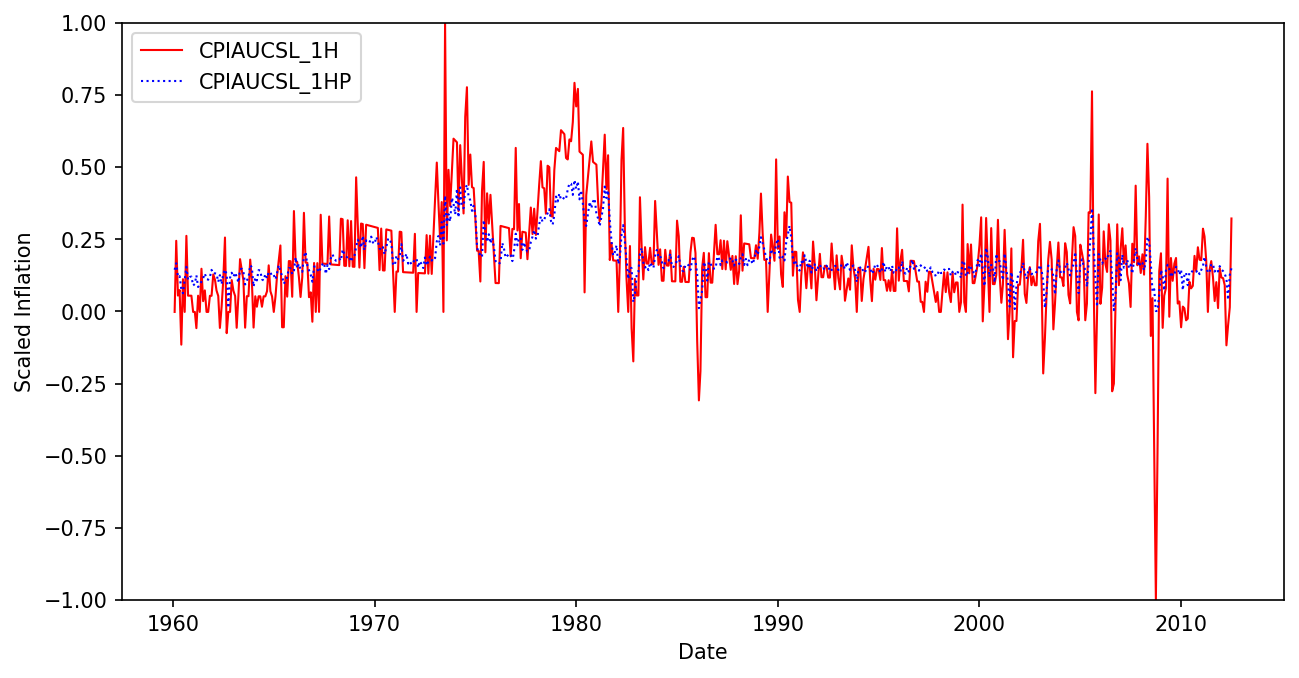

In [ ]:
# plot prediction on train set
prediction = GBM.predict(GBM_x_train)
visualize_predict(prediction, GBM_y_train, 1, FRED_MD)

Test MSE:0.0256745240136982, Test RMSE:0.16023271829966002


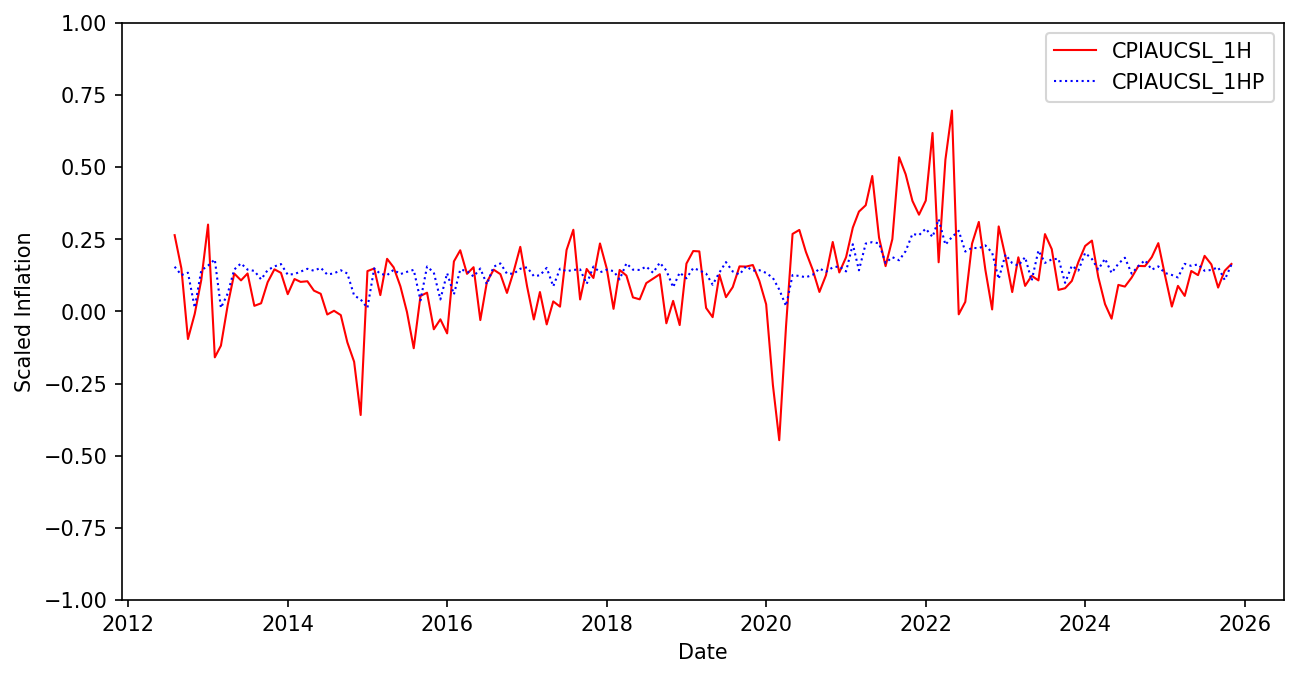

In [ ]:
# plot prediction on test set
prediction = GBM.predict(GBM_x_test)
visualize_predict(prediction, GBM_y_test, 1, FRED_MD)
GBM_MSE, GBM_RMSE = compute_MSE(prediction, GBM_y_test)
print(f"Test MSE:{GBM_MSE}, Test RMSE:{GBM_RMSE}")

## Multi-period Ahead Prediction

In [ ]:
# set up the dictionary to store all predictions / loss metrics for multi-periods ahead predictions
multi_period_prediction = {}
multi_period_RMSE = {}

### FNN

In [ ]:
# train 20 FNNs for each forecasting horizon, store ensembled prediction, MSE, and RMSE on test set
multi_period_prediction["MLP"] = {}
multi_period_RMSE["MLP"] = {}
for ahead in [1, 3, 6, 12, 24]:
    MLP_y_train, MLP_x_train, MLP_y_test, MLP_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, 0, include_target = True, target_lag = 11)
    nodes = MLP_best_param["node_size"]
    lr = MLP_best_param["learning_rate"]
    epochs = MLP_best_param["epochs"]
    prediction, _ = MLP_ensemble(nodes, lr, epochs, 20, MLP_x_train, MLP_y_train, MLP_x_test, MLP_y_test)
    multi_period_prediction["MLP"][ahead] = prediction
    MSE, RMSE = compute_MSE(prediction, MLP_y_test)
    multi_period_RMSE["MLP"][ahead] = RMSE

### LSTM

In [ ]:
# train 20 LSTMs for each forecasting horizon, store ensembled prediction, MSE, and RMSE on test set
multi_period_prediction["LSTM"] = {}
multi_period_RMSE["LSTM"] = {}
for ahead in [1, 3, 6, 12, 24]:
    RNN_y_train, RNN_x_train, RNN_y_test, RNN_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, 0, include_target = True, target_lag = 0)
    nodes = RNN_best_param["node_size"]
    hidden_size = RNN_best_param["hidden_size"]
    window_size = RNN_best_param["window_size"]
    prediction, _ = RNN_ensemble(nodes, hidden_size, window_size, 20, RNN_x_train, RNN_y_train, RNN_x_test, RNN_y_test)
    multi_period_prediction["LSTM"][ahead] = prediction
    MSE, RMSE = compute_MSE(prediction, RNN_y_test)
    multi_period_RMSE["LSTM"][ahead] = RMSE

### Dlinear

In [ ]:
# train 20 DLs for each forecasting horizon, store ensembled prediction, MSE, and RMSE on test set
multi_period_prediction["DL"] = {}
multi_period_RMSE["DL"] = {}
for ahead in [1, 3, 6, 12, 24]:
    DL_y_train, DL_x_train, DL_y_test, DL_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, -1, include_target = True, target_lag = 0)
    kernel_size = DL_best_param["kernel_size"]
    window_size = DL_best_param["window_size"]
    prediction, _ = DL_ensemble(kernel_size, True, window_size, 20, DL_x_train, DL_y_train, DL_x_test, DL_y_test)
    multi_period_prediction["DL"][ahead] = prediction
    MSE, RMSE = compute_MSE(prediction, DL_y_test)
    multi_period_RMSE["DL"][ahead] = RMSE

### AR

In [ ]:
# train AR for each forecasting horizon, store prediction, MSE, and RMSE on test set
multi_period_prediction["AR"] = {}
multi_period_RMSE["AR"] = {}
for ahead in [1, 3, 6, 12, 24]:
    lag = AR_best_param["lag"]
    AR_y_train, AR_x_train, AR_y_test, AR_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, -1, include_target = True, target_lag = lag)
    AR_model = LinearRegression()
    AR_model.fit(AR_x_train, AR_y_train)
    prediction = AR_model.predict(AR_x_test)
    multi_period_prediction["AR"][ahead] = prediction
    MSE, RMSE = compute_MSE(prediction, AR_y_test)
    multi_period_RMSE["AR"][ahead] = RMSE

### ARDL

In [ ]:
# train ARDL for each forecasting horizon, store prediction, MSE, and RMSE on test set
multi_period_prediction["ARDL"] = {}
multi_period_RMSE["ARDL"] = {}
for ahead in [1, 3, 6, 12, 24]:
    x_lag = ARDL_best_param["x_lag"]
    y_lag = ARDL_best_param["y_lag"]
    ARDL_y_train, ARDL_x_train, ARDL_y_test, ARDL_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, x_lag, include_target = True, target_lag = y_lag - 1)
    ARDL_model = LinearRegression()
    ARDL_model.fit(ARDL_x_train, ARDL_y_train)
    prediction = ARDL_model.predict(ARDL_x_test)
    multi_period_prediction["ARDL"][ahead] = prediction
    MSE, RMSE = compute_MSE(prediction, ARDL_y_test)
    multi_period_RMSE["ARDL"][ahead] = RMSE

### LASSO

In [ ]:
# train LASSO for each forecasting horizon, store prediction, MSE, and RMSE on test set
multi_period_prediction["LASSO"] = {}
multi_period_RMSE["LASSO"] = {}
for ahead in [1, 3, 6, 12, 24]:
    LASSO_y_train, LASSO_x_train, LASSO_y_test, LASSO_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, 11, include_target = True, target_lag = 11)
    alpha = LASSO_best_param["alpha"]
    LASSO = Pipeline([("scaler", StandardScaler()),("LASSO", Lasso(alpha = alpha))])
    LASSO.fit(LASSO_x_train, LASSO_y_train)
    prediction = LASSO.predict(LASSO_x_test)
    multi_period_prediction["LASSO"][ahead] = prediction
    MSE, RMSE = compute_MSE(prediction, LASSO_y_test)
    multi_period_RMSE["LASSO"][ahead] = RMSE

### Random Forest

In [ ]:
# train random forest for each forecasting horizon, store prediction, MSE, and RMSE on test set
multi_period_prediction["RF"] = {}
multi_period_RMSE["RF"] = {}
for ahead in [1, 3, 6, 12, 24]:
    RF_y_train, RF_x_train, RF_y_test, RF_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, 11, include_target = True, target_lag = 11)
    n_estimator = RF_best_param["n_estimator"]
    min_samples_split = RF_best_param["min_samples_split"]
    RF = RandomForestRegressor(n_estimators = n_estimator, min_samples_split = min_samples_split)
    RF.fit(RF_x_train, RF_y_train)
    prediction = RF.predict(RF_x_test)
    multi_period_prediction["RF"][ahead] = prediction
    MSE, RMSE = compute_MSE(prediction, RF_y_test)
    multi_period_RMSE["RF"][ahead] = RMSE

### Gradient Boosting Machine

In [ ]:
# train GBM for each forecasting horizon, store prediction, MSE, and RMSE on test set
multi_period_prediction["GBM"] = {}
multi_period_RMSE["GBM"] = {}
for ahead in [1, 3, 6, 12, 24]:
    GBM_y_train, GBM_x_train, GBM_y_test, GBM_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, 11, include_target = True, target_lag = 11)
    n_estimator = GBM_best_param["n_estimator"]
    learning_rate = GBM_best_param["learning_rate"]
    max_depth = GBM_best_param["max_depth"]
    GBM = LGBMRegressor(objective="mse", n_estimators = n_estimator, learning_rate = learning_rate, max_depth = max_depth, verbosity=-1)
    GBM.fit(GBM_x_train, GBM_y_train)
    prediction = GBM.predict(GBM_x_test)
    multi_period_prediction["GBM"][ahead] = prediction
    MSE, RMSE = compute_MSE(prediction, GBM_y_test)
    multi_period_RMSE["GBM"][ahead] = RMSE

## Evaluation

In [124]:
# combine RMSE from different prediction horizons intwo one dataframe
RMSE_df = pd.DataFrame.from_dict(multi_period_RMSE, orient = "index")
RMSE_df

,1,3,6,12,24
MLP,0.114332,0.135670,0.139502,0.161337,0.168115
LSTM,0.141629,0.131050,0.126343,0.128918,0.161548
DL,0.142834,0.138936,0.144493,0.153986,0.164993
AR,0.122822,0.138505,0.141455,0.151483,0.166403
ARDL,0.121084,0.151817,0.149459,0.173799,0.179282
LASSO,0.174820,0.175130,0.169815,0.176206,0.177103
RF,0.167525,0.165861,0.167492,0.169211,0.172916
GBM,0.160233,0.160685,0.161715,0.160478,0.162590


In [125]:
# compute the performance of each model relative to AR
RMSE_ratio = RMSE_df.div(RMSE_df.loc["AR"])
RMSE_ratio = (RMSE_ratio*100).round(2)
RMSE_ratio

,1,3,6,12,24
MLP,93.09,97.95,98.62,106.50,101.03
LSTM,115.31,94.62,89.32,85.10,97.08
DL,116.29,100.31,102.15,101.65,99.15
AR,100.00,100.00,100.00,100.00,100.00
ARDL,98.59,109.61,105.66,114.73,107.74
LASSO,142.34,126.44,120.05,116.32,106.43
RF,136.40,119.75,118.41,111.70,103.91
GBM,130.46,116.01,114.32,105.94,97.71


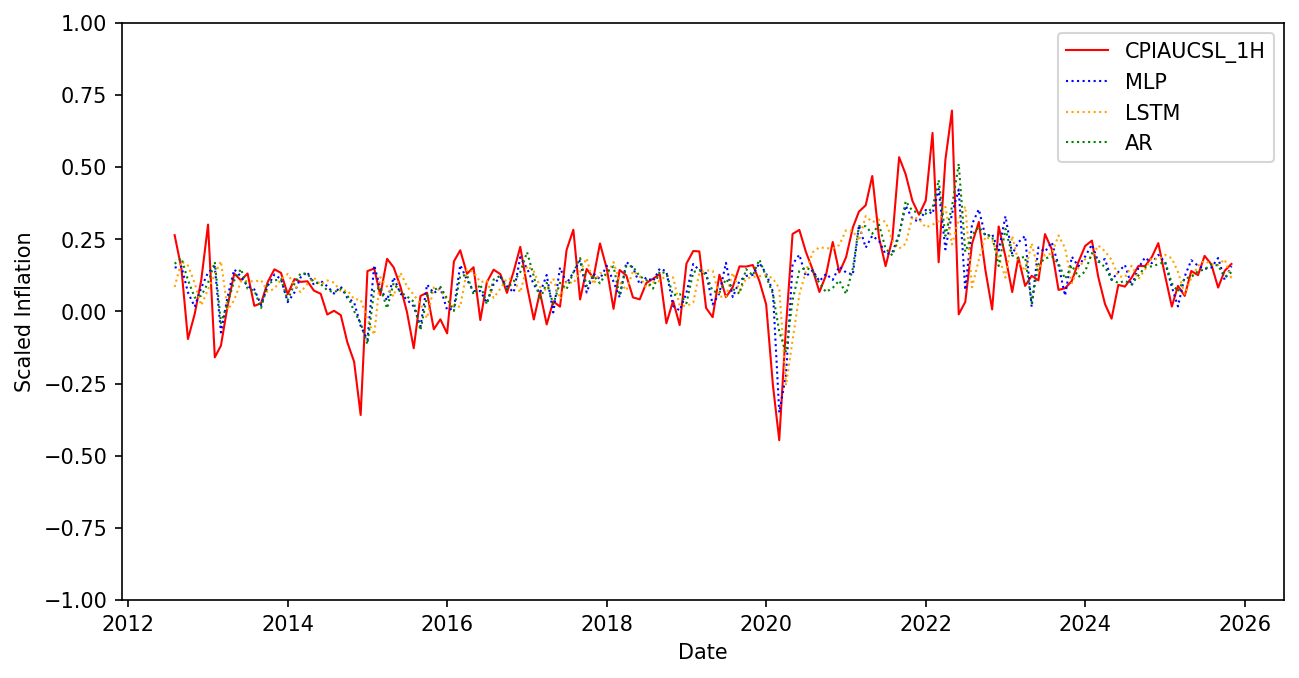

In [ ]:
# plot the prediction by AR, FNN, and LSTM for 1-period-ahead forecasting
ahead = 1
_, _, Y_temp, _ = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, 0, include_target = True, target_lag = 11)
Y_temp["MLP"] = multi_period_prediction["MLP"][ahead]
Y_temp["LSTM"] = multi_period_prediction["LSTM"][ahead]
Y_temp["AR"] = multi_period_prediction["AR"][ahead]
Y_date = Y_temp.merge(FRED_MD["sasdate"], left_index=True, right_index=True, how="left")
visualize_series(Y_date, [f"CPIAUCSL_{ahead}H", "MLP", "LSTM", "AR"], "Scaled Inflation", -1, 1, recession = False)

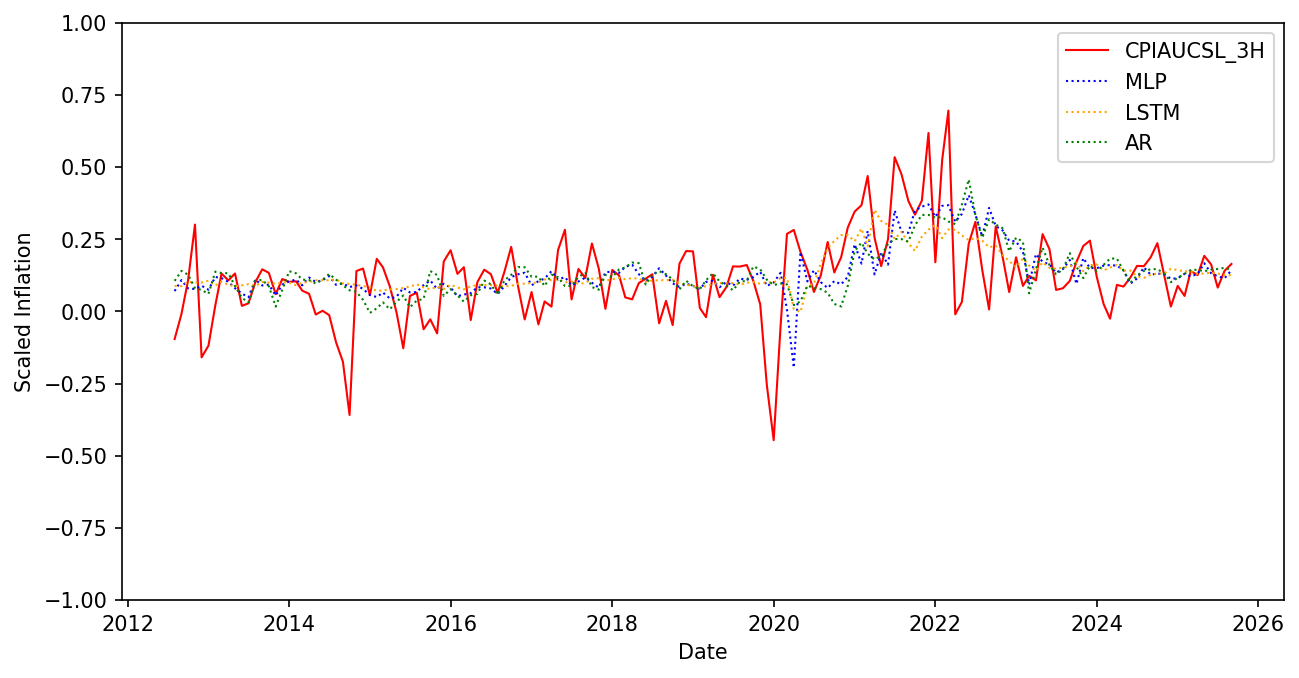

In [ ]:
# plot the prediction by AR, FNN, and LSTM for 3-periods-ahead forecasting
ahead = 3
_, _, Y_temp, _ = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, 0, include_target = True, target_lag = 11)
Y_temp["MLP"] = multi_period_prediction["MLP"][ahead]
Y_temp["LSTM"] = multi_period_prediction["LSTM"][ahead]
Y_temp["AR"] = multi_period_prediction["AR"][ahead]
Y_date = Y_temp.merge(FRED_MD["sasdate"], left_index=True, right_index=True, how="left")
visualize_series(Y_date, [f"CPIAUCSL_{ahead}H", "MLP", "LSTM", "AR"], "Scaled Inflation", -1, 1, recession = False)

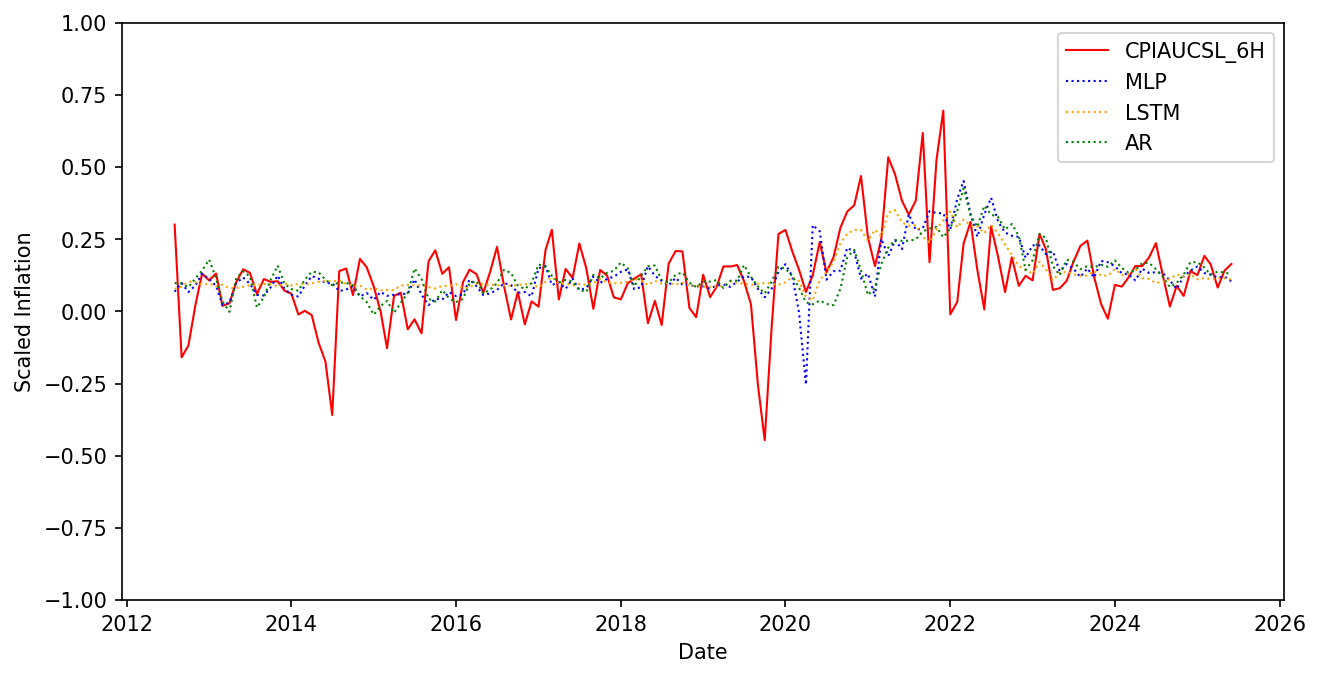

In [ ]:
# plot the prediction by AR, FNN, and LSTM for 6-periods-ahead forecasting
ahead = 6
_, _, Y_temp, _ = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, 0, include_target = True, target_lag = 11)
Y_temp["MLP"] = multi_period_prediction["MLP"][ahead]
Y_temp["LSTM"] = multi_period_prediction["LSTM"][ahead]
Y_temp["AR"] = multi_period_prediction["AR"][ahead]
Y_date = Y_temp.merge(FRED_MD["sasdate"], left_index=True, right_index=True, how="left")
visualize_series(Y_date, [f"CPIAUCSL_{ahead}H", "MLP", "LSTM", "AR"], "Scaled Inflation", -1, 1, recession = False)

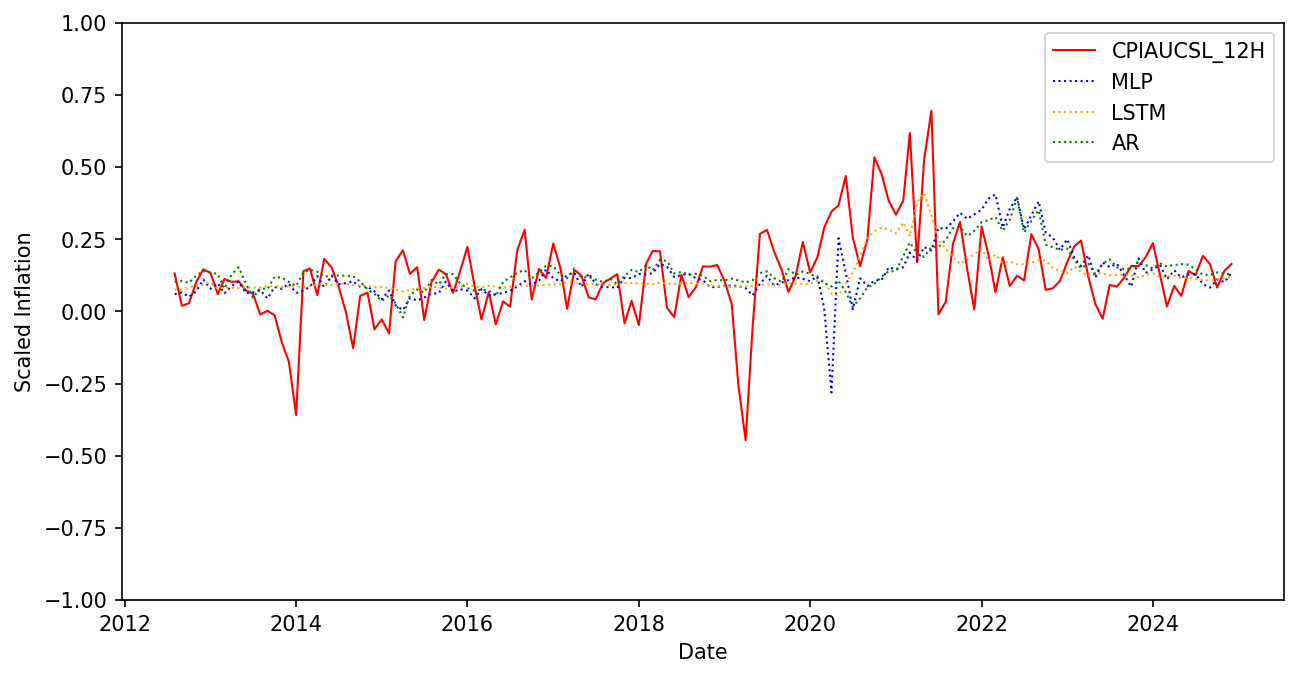

In [ ]:
# plot the prediction by AR, FNN, and LSTM for 12-periods-ahead forecasting
ahead = 12
_, _, Y_temp, _ = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, 0, include_target = True, target_lag = 11)
Y_temp["MLP"] = multi_period_prediction["MLP"][ahead]
Y_temp["LSTM"] = multi_period_prediction["LSTM"][ahead]
Y_temp["AR"] = multi_period_prediction["AR"][ahead]
Y_date = Y_temp.merge(FRED_MD["sasdate"], left_index=True, right_index=True, how="left")
visualize_series(Y_date, [f"CPIAUCSL_{ahead}H", "MLP", "LSTM", "AR"], "Scaled Inflation", -1, 1, recession = False)

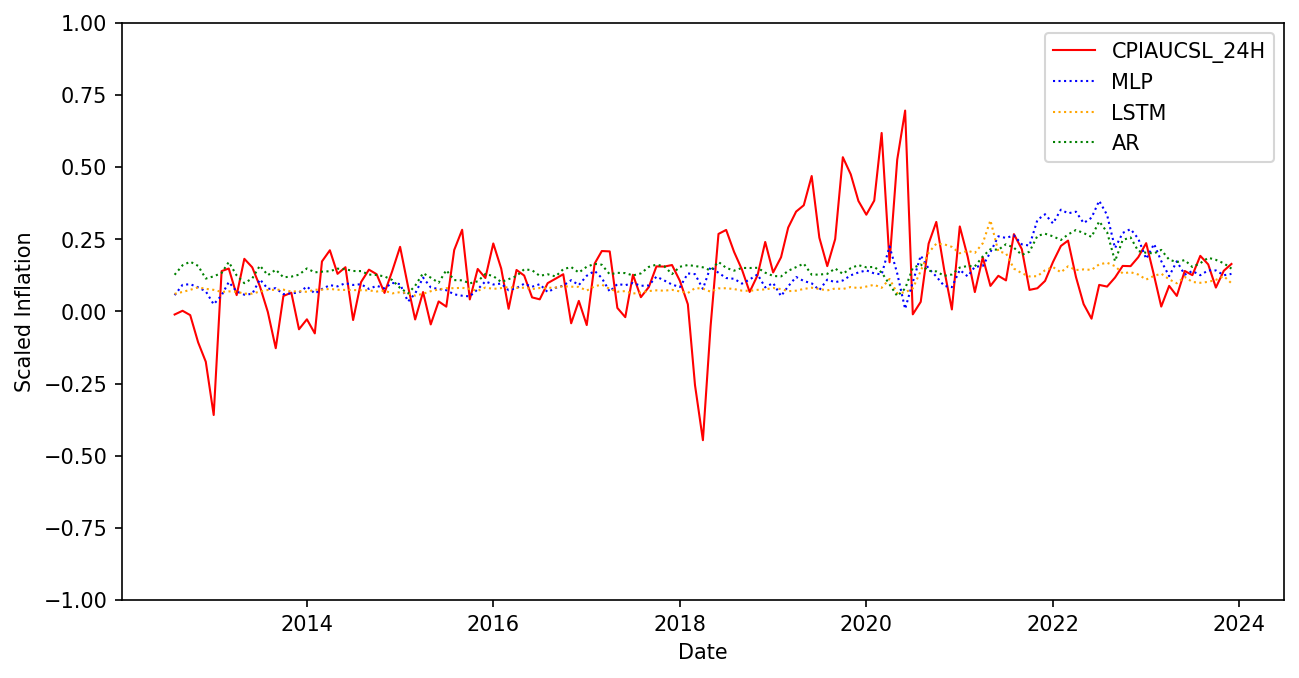

In [ ]:
# plot the prediction by AR, FNN, and LSTM for 24-periods-ahead forecasting
ahead = 24
_, _, Y_temp, _ = create_ahead_lag(y_train, x_train, y_test, x_test, ahead, 0, include_target = True, target_lag = 11)
Y_temp["MLP"] = multi_period_prediction["MLP"][ahead]
Y_temp["LSTM"] = multi_period_prediction["LSTM"][ahead]
Y_temp["AR"] = multi_period_prediction["AR"][ahead]
Y_date = Y_temp.merge(FRED_MD["sasdate"], left_index=True, right_index=True, how="left")
visualize_series(Y_date, [f"CPIAUCSL_{ahead}H", "MLP", "LSTM", "AR"], "Scaled Inflation", -1, 1, recession = False)